# Análisis de sentimientos en Twitter (X)

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('/content/Tweets.csv')

In [46]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [47]:
print("El dataset tiene {} filas y {} columnas.".format(df.shape[0],df.shape[1]))

El dataset tiene 14640 filas y 15 columnas.


# Transformación y limpieza de datos

## Duplicados



In [48]:
print(f"Hay {df.duplicated().sum()} duplicados en el dataset")

Hay 36 duplicados en el dataset


In [49]:
df.drop_duplicates(inplace = True)
# print the data set information as number of rows and columns
print(f"Hay {df.duplicated().sum()} duplicados en el dataset.")

Hay 0 duplicados en el dataset.


## Nulos

In [50]:
nulos = pd.DataFrame({
    'Valores Nulos': df.isnull().sum(),
    'Porcentaje de Nulos': ((df.isnull().mean() * 100).round(2)).astype(str) + '%'})
print(f"{nulos}")

                              Valores Nulos Porcentaje de Nulos
tweet_id                                  0                0.0%
airline_sentiment                         0                0.0%
airline_sentiment_confidence              0                0.0%
negativereason                         5445              37.28%
negativereason_confidence              4101              28.08%
airline                                   0                0.0%
airline_sentiment_gold                14564              99.73%
name                                      0                0.0%
negativereason_gold                   14572              99.78%
retweet_count                             0                0.0%
text                                      0                0.0%
tweet_coord                           13589              93.05%
tweet_created                             0                0.0%
tweet_location                         4723              32.34%
user_timezone                          4

## Analisis de columnas

In [51]:
df["tweet_coord"].value_counts()

,count
tweet_coord,
"[0.0, 0.0]",162
"[40.64656067, -73.78334045]",6
"[40.64646912, -73.79133606]",3
"[32.91792297, -97.00367737]",3
"[37.78618135, -122.45742542]",2
...,...
"[40.69429232, -74.17208436]",1
"[37.61833841, -122.38389799]",1
"[37.61859126, -122.38385699]",1


In [52]:
df["user_timezone"].value_counts()

,count
user_timezone,
Eastern Time (US & Canada),3738
Central Time (US & Canada),1923
Pacific Time (US & Canada),1206
Quito,733
Atlantic Time (Canada),496
...,...
Warsaw,1
Bucharest,1
Wellington,1


Se eliminan las columnas ya que no aportan informacion relevante para analisis

In [53]:
df.drop(['negativereason_confidence','airline_sentiment_gold',
           'negativereason_gold','tweet_coord','tweet_location',
           'user_timezone'],axis=1,inplace=True)

df['negativereason'] =  df['negativereason'].fillna('N/A')

df.isna().sum()

,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,0
airline,0
name,0
retweet_count,0
text,0
tweet_created,0


Esta columna es interesante para el analisis exploratorio, pero para la realizacion de los modelos no es necesario. Es por esto que se completan los nulos con "N/A" para analizar los valores con otras categorias.

In [54]:
df['negativereason'] =  df['negativereason'].fillna('N/A')

Eliminamos 'tweet_id' porque es un identificador único que no aporta valor analítico. Sirvio para poder identificar las filas duplicadas, pero luego de esto, no es más necesaria.

In [55]:
df.drop('tweet_id',axis=1,inplace=True)

##### tweet_created

In [56]:
df["tweet_created"].value_counts()

,count
tweet_created,
2015-02-24 09:54:34 -0800,5
2015-02-24 11:43:05 -0800,4
2015-02-23 14:18:58 -0800,3
2015-02-24 11:32:49 -0800,3
2015-02-23 06:57:24 -0800,3
...,...
2015-02-22 18:44:20 -0800,1
2015-02-22 18:42:36 -0800,1
2015-02-22 18:40:39 -0800,1


Se busca verificar si todos los valores de la columna de fechas terminan con '-0800'

In [57]:
all_end_with_0800 = df['tweet_created'].str.endswith('-0800').all()

if all_end_with_0800:
    print("Todos los valores en 'tweet_created' terminan con -0800.")
else:
    print("Hay valores en 'tweet_created' que no terminan con -0800.")

Todos los valores en 'tweet_created' terminan con -0800.


Como nos aseguramos que todas las filas lo contienen, se eliminan

In [58]:
df['tweet_created'] = df['tweet_created'].str.replace(' -0800', '', regex=False)

Se separan en date y time

In [59]:
# Dividir la columna en fecha y horario
df[['date', 'time']] = df['tweet_created'].str.split(' ', n=1, expand=True)
df[["tweet_created",'date', 'time']]

,tweet_created,date,time
0,2015-02-24 11:35:52,2015-02-24,11:35:52
1,2015-02-24 11:15:59,2015-02-24,11:15:59
2,2015-02-24 11:15:48,2015-02-24,11:15:48
3,2015-02-24 11:15:36,2015-02-24,11:15:36
4,2015-02-24 11:14:45,2015-02-24,11:14:45
...,...,...,...
14635,2015-02-22 12:01:01,2015-02-22,12:01:01
14636,2015-02-22 11:59:46,2015-02-22,11:59:46
14637,2015-02-22 11:59:15,2015-02-22,11:59:15
14638,2015-02-22 11:59:02,2015-02-22,11:59:02


## Análisis exploratorio de datos

In [60]:
df["airline_sentiment"].value_counts()

,count
airline_sentiment,
negative,9159
neutral,3091
positive,2354


<ipython-input-61-8783bb9b112f>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


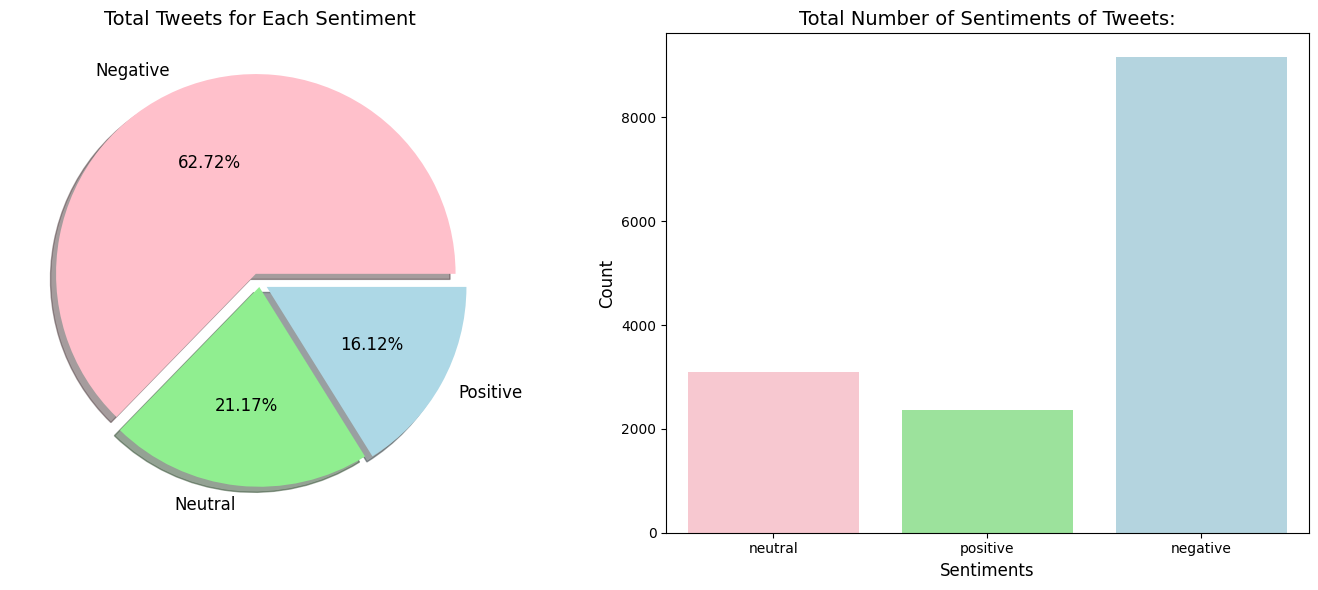

In [61]:
# Crear figura con subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Definir paleta de colores específica
colors = ['pink', 'lightgreen', 'lightblue']  # Rosa para Negative, verde para Neutral, azul para Positive

# Gráfico de pastel
pd.Series(df['airline_sentiment']).value_counts().plot(
    kind='pie',
    colors=colors,  # Aplicar la paleta definida
    labels=['Negative', 'Neutral', 'Positive'],  # Asegúrate de que coincidan con los valores en tu dataset
    explode=[0.05, 0.02, 0.04],
    shadow=True,
    autopct='%.2f%%',
    fontsize=12,
    ax=axes[0]
)
axes[0].set_title('Total Tweets for Each Sentiment', fontsize=14)
axes[0].set_ylabel('')  # Ocultar etiqueta de eje Y

# Gráfico de barras
sns.countplot(
    x="airline_sentiment",
    data=df,
    ax=axes[1],
    palette=colors  # Usar la misma paleta
)
axes[1].set_title('Total Number of Sentiments of Tweets:', fontsize=14)
axes[1].set_xlabel('Sentiments', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

# Ajustar diseño
plt.tight_layout()
plt.show()


<ipython-input-62-a6e33be0c05c>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="airline", data=df, palette=colors)


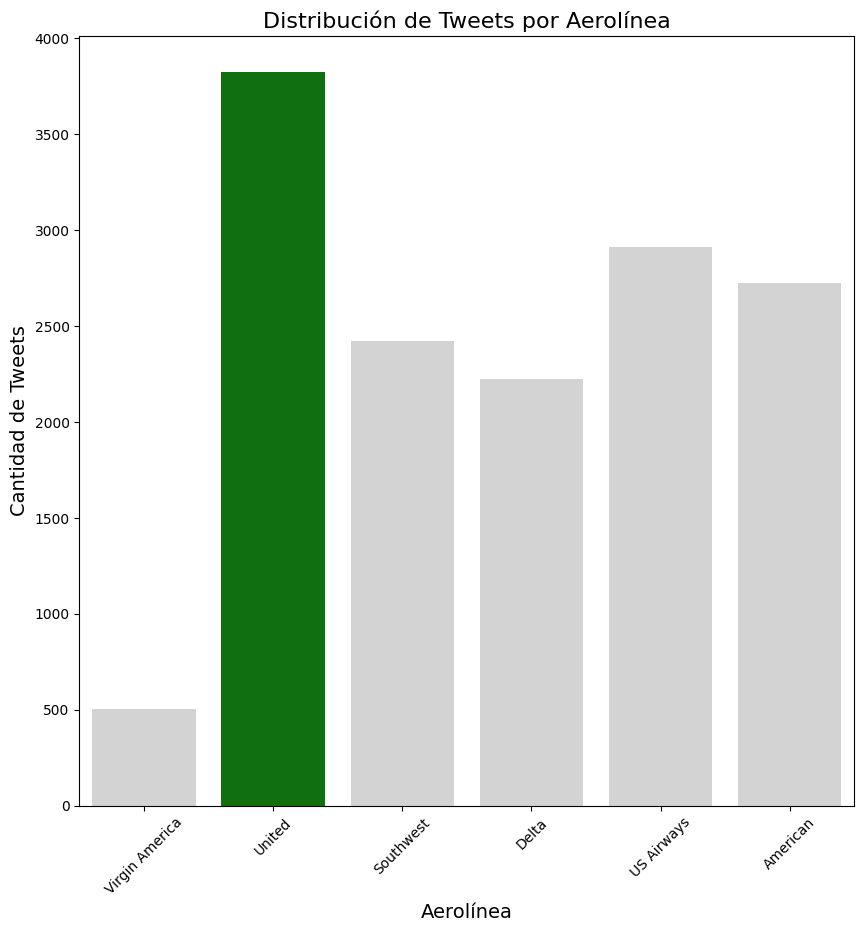

In [62]:
# Definir los colores
colors = ['green' if airline == 'United' else 'lightgray' for airline in df['airline'].unique()]

# Crear el gráfico
plt.figure(figsize=(10, 10))
ax = sns.countplot(x="airline", data=df, palette=colors)

# Personalizar etiquetas y título
plt.title("Distribución de Tweets por Aerolínea", fontsize=16)
plt.xlabel("Aerolínea", fontsize=14)
plt.ylabel("Cantidad de Tweets", fontsize=14)
plt.xticks(rotation=45)
plt.show()

En la base, hay mas datos de United.

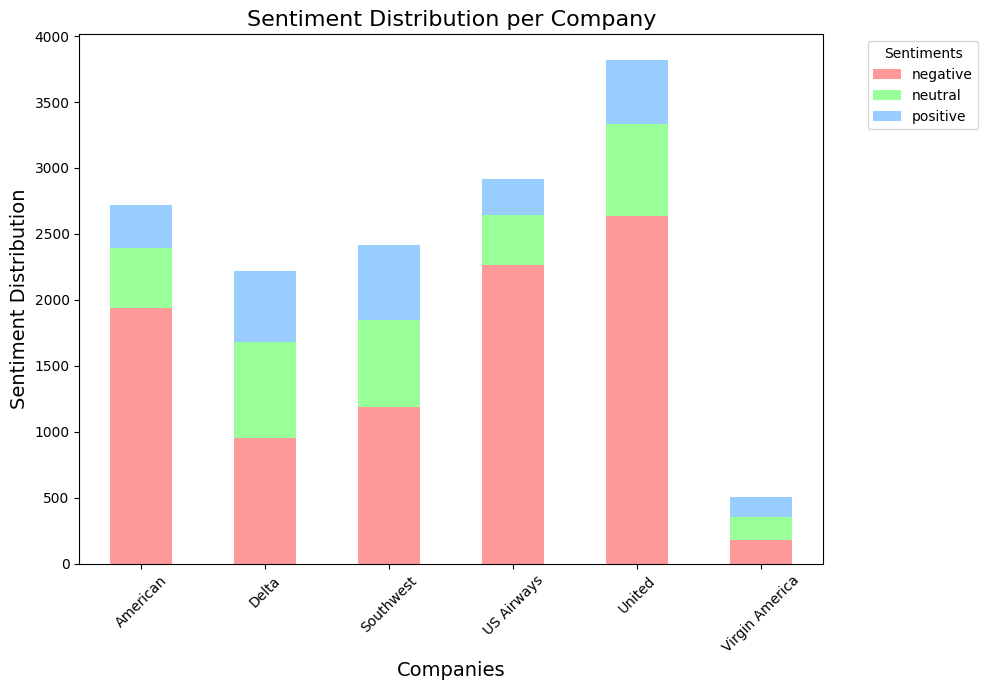

In [63]:
crosstab_sentiments = pd.crosstab(df.airline, df.airline_sentiment)

# Definir colores suaves
colors = ['#FF9999', '#99FF99', '#99CCFF']  # Tonos pastel: rojo claro, verde claro, azul claro

# Crear el gráfico de barras apiladas
crosstab_sentiments.plot(kind='bar', stacked=True, figsize=(10, 7), color=colors)

# Personalizar el gráfico
plt.title('Sentiment Distribution per Company', fontsize=16)
plt.xlabel('Companies', fontsize=14)
plt.ylabel('Sentiment Distribution', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Sentiments', bbox_to_anchor=(1.05, 1), loc='upper left')  # Coloca la leyenda fuera del gráfico
plt.tight_layout()  # Ajusta el diseño para que no se superpongan elementos
plt.show()

<Axes: xlabel='airline', ylabel='count'>

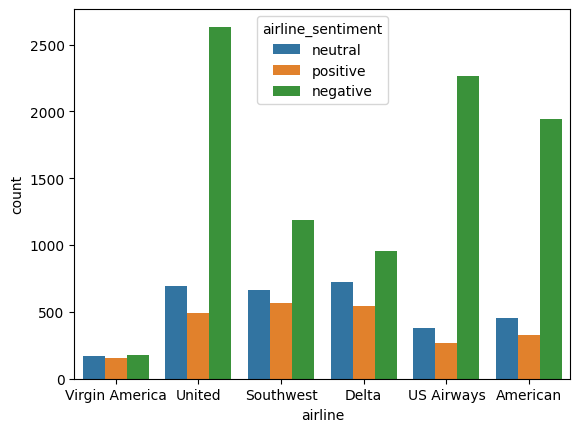

In [64]:
sns.countplot(x=df['airline'],hue=df['airline_sentiment'])

In [65]:
neg_review = df[df['airline_sentiment']=='negative']

total_neg = pd.DataFrame(neg_review.groupby('airline')['airline_sentiment'].count())
total_neg = total_neg.reset_index()

all_review = pd.DataFrame(df.groupby('airline')['airline_sentiment'].count()).reset_index()
all_review.columns = ['airline','total_reviews']

all_review['neg_reviews'] = total_neg['airline_sentiment']
all_review['neg_percent_reviews'] = all_review['neg_reviews'] / all_review['total_reviews']
all_review

,airline,total_reviews,neg_reviews,neg_percent_reviews
0,American,2723,1941,0.712817
1,Delta,2222,955,0.429793
2,Southwest,2420,1186,0.490083
3,US Airways,2913,2263,0.776862
4,United,3822,2633,0.688906
5,Virgin America,504,181,0.359127


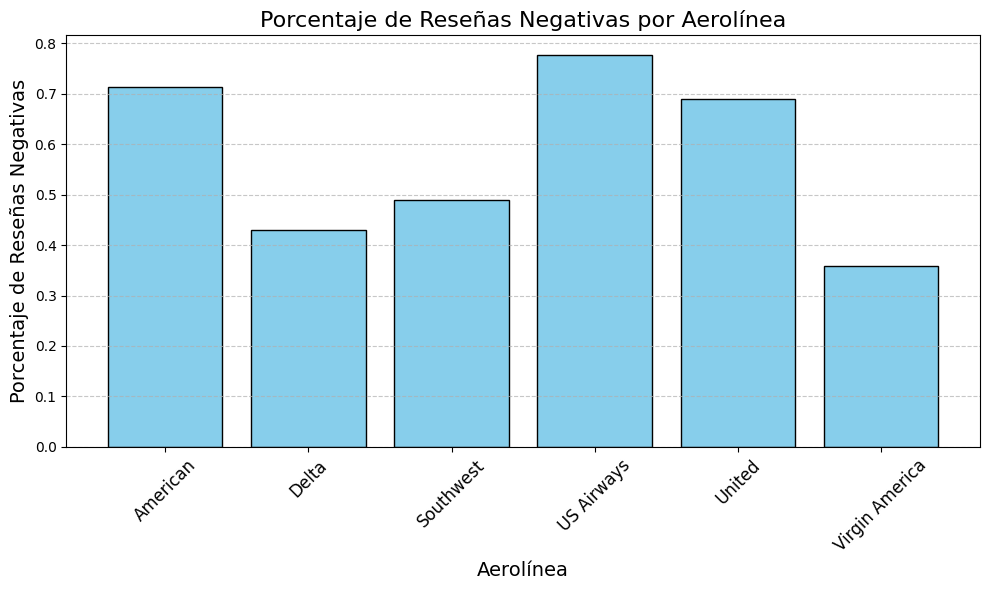

In [66]:
# Crear un gráfico de barras para representar neg_percent_reviews por aerolínea
plt.figure(figsize=(10, 6))
plt.bar(all_review['airline'], all_review['neg_percent_reviews'], color='skyblue', edgecolor='black')

# Agregar títulos y etiquetas
plt.title('Porcentaje de Reseñas Negativas por Aerolínea', fontsize=16)
plt.xlabel('Aerolínea', fontsize=14)
plt.ylabel('Porcentaje de Reseñas Negativas', fontsize=14)
plt.xticks(rotation=45, fontsize=12)  # Rotar las etiquetas del eje X
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


In [67]:
df['tweet_created'].value_counts()

,count
tweet_created,
2015-02-24 09:54:34,5
2015-02-24 11:43:05,4
2015-02-23 14:18:58,3
2015-02-24 11:32:49,3
2015-02-23 06:57:24,3
...,...
2015-02-22 18:44:20,1
2015-02-22 18:42:36,1
2015-02-22 18:40:39,1


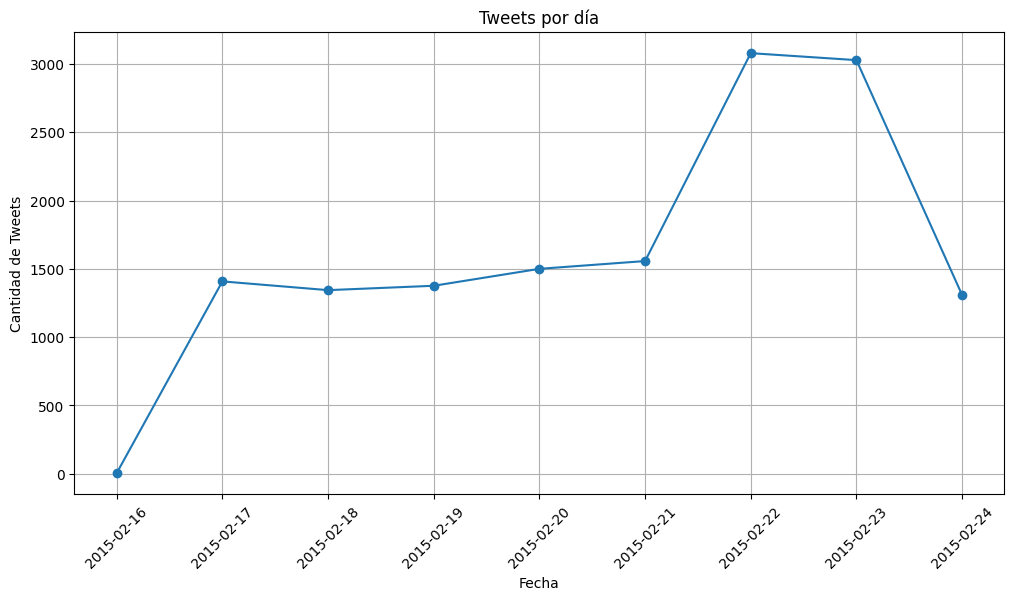

In [68]:
# Asegurar de que la columna está en formato datetime
df['tweet_created'] = pd.to_datetime(df['tweet_created'])

# Ejemplo de agrupación por día para contar tweets
df_grouped = df['tweet_created'].dt.date.value_counts().sort_index()

# Crear el gráfico
plt.figure(figsize=(12, 6))
df_grouped.plot(kind='line', marker='o', linestyle='-', title='Tweets por día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Tweets')
plt.xticks(rotation=45)
plt.grid()
plt.show()

Son tweets entre el 16 al 24 de febrero

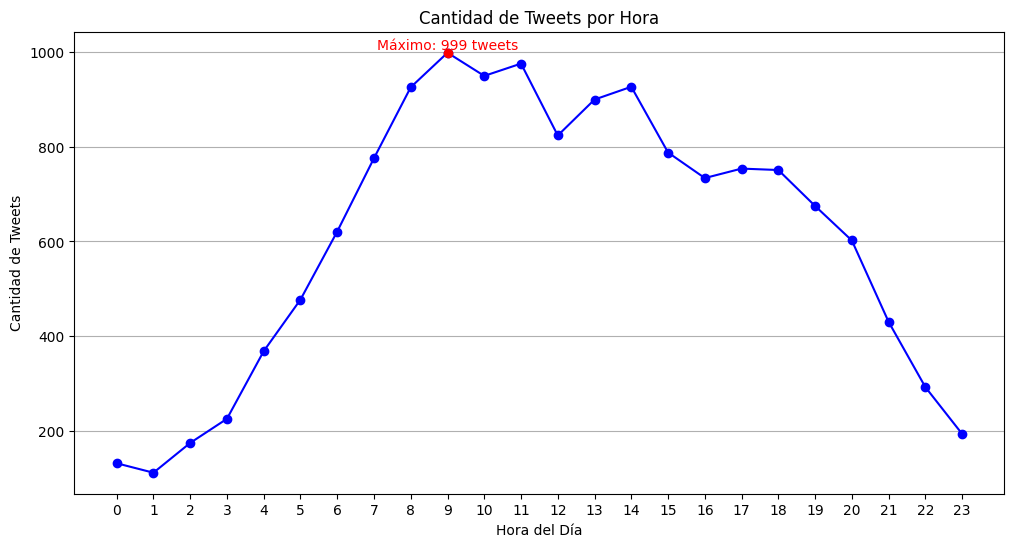

In [69]:
# Asegurar de extraer las horas de la columna 'time'
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

# Agrupar por horas y contar la cantidad de tweets
hourly_counts = df['hour'].value_counts().sort_index()

# Crear el gráfico de línea
plt.figure(figsize=(12, 6))
hourly_counts.plot(kind='line', marker='o', linestyle='-', color='blue', title='Cantidad de Tweets por Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Cantidad de Tweets')
plt.xticks(range(0, 24))  # Asegura que todas las horas estén en el eje X
plt.grid(axis='y')

# Resaltar el horario con más tweets
max_hour = hourly_counts.idxmax()
max_count = hourly_counts.max()
plt.scatter(max_hour, max_count, color='red', zorder=5)  # Punto rojo en el pico
plt.text(max_hour, max_count, f'Máximo: {max_count} tweets', color='red', ha='center', va='bottom')

plt.show()

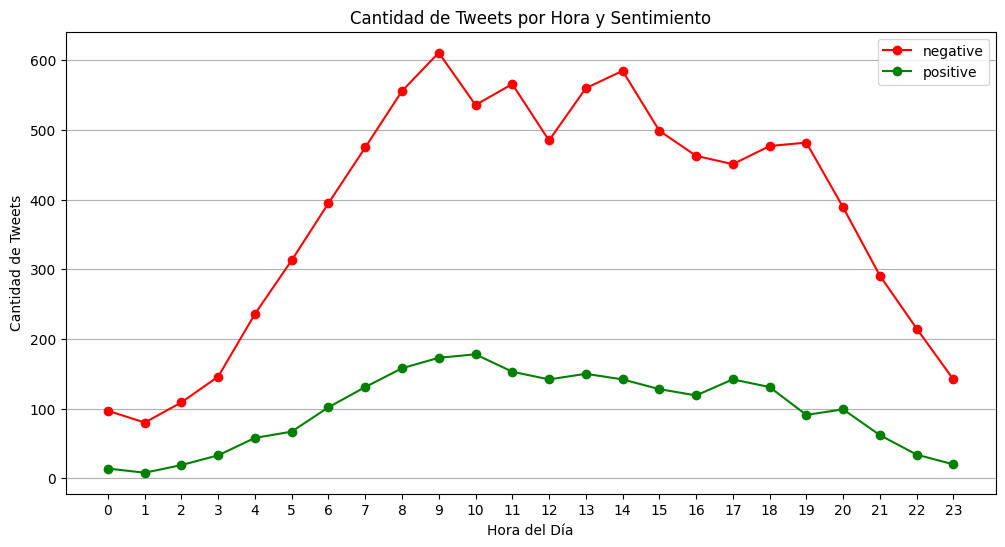

In [70]:
# Asegúrate de extraer las horas de la columna 'time'
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

# Filtrar por sentimientos y contar tweets por hora
hourly_counts_negative = df[df['airline_sentiment'] == 'negative']['hour'].value_counts().sort_index()
hourly_counts_positive = df[df['airline_sentiment'] == 'positive']['hour'].value_counts().sort_index()

# Crear el gráfico
plt.figure(figsize=(12, 6))

# Línea para sentimientos negativos
plt.plot(hourly_counts_negative.index, hourly_counts_negative.values, marker='o', linestyle='-', color='red', label='negative')

# Línea para sentimientos positivos
plt.plot(hourly_counts_positive.index, hourly_counts_positive.values, marker='o', linestyle='-', color='green', label='positive')

# Configuración del gráfico
plt.title('Cantidad de Tweets por Hora y Sentimiento')
plt.xlabel('Hora del Día')
plt.ylabel('Cantidad de Tweets')
plt.xticks(range(0, 24))  # Mostrar todas las horas en el eje X
plt.legend()  # Mostrar leyenda
plt.grid(axis='y')

# Mostrar el gráfico
plt.show()


In [71]:
# Ordenar el DataFrame por retweet_count en orden descendente
top_retweets = df.sort_values(by='retweet_count', ascending=False)

# Seleccionar las columnas 'text' y 'retweet_count' de los tweets más retuiteados
top_retweets = top_retweets[['text', 'retweet_count']].head(10)  # Cambia el número para ver más o menos tweets
top_retweets

,text,retweet_count
11596,@USAirways 5 hr flight delay and a delay when ...,44
11582,@USAirways of course never again tho . Thanks ...,32
7132,STOP. USING.THIS.WORD. IF. YOU'RE. A. COMPANY....,31
9999,@USAirways with this livery back in the day. h...,28
5607,@SouthwestAir beautiful day in Seattle! http:/...,22
7115,can you not? RT @JetBlue Our fleet's on fleek....,22
7027,"Just in case you needed confirmation that ""on ...",18
7111,X____x RT @JetBlue: Our fleet's on fleek. http...,15
7453,@JetBlue what a great experience on flight fro...,11
9453,@USAirways Wow unbelievable how you treat your...,9


<Axes: ylabel='count'>

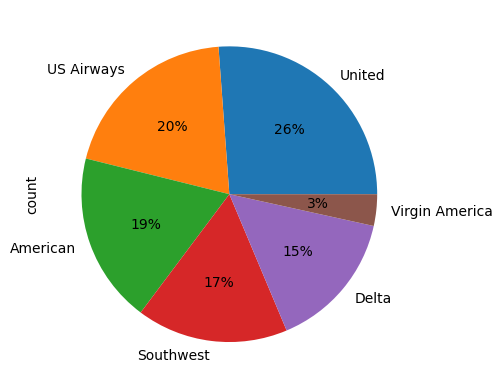

In [72]:
df.airline.value_counts().plot(kind='pie', autopct='%1.0f%%')

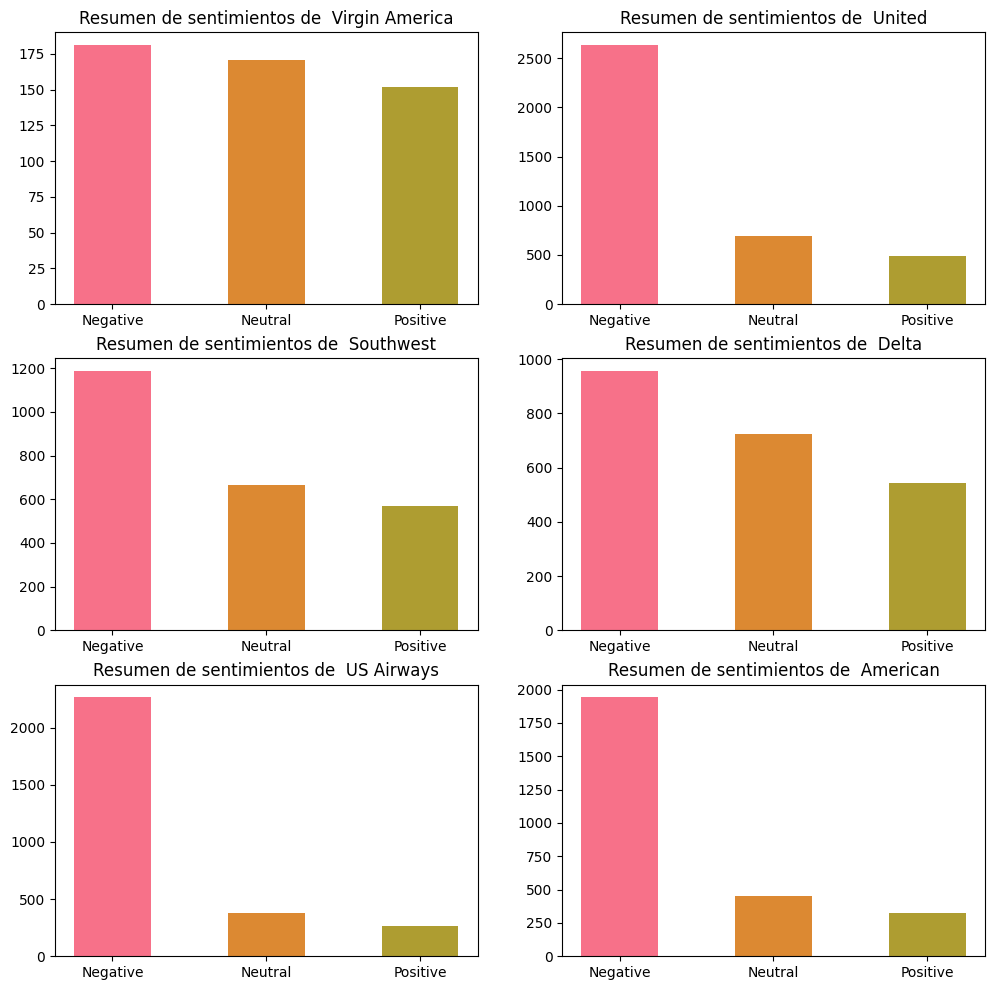

In [73]:

def plot_sub_sentiment(Airline):
    pdf = df[df['airline']==Airline]
    count = pdf['airline_sentiment'].value_counts()
    Index = [1,2,3]
    color=sns.color_palette("husl", 10)
    plt.bar(Index,count,width=0.5,color=color)
    plt.xticks(Index,['Negative','Neutral','Positive'])
    plt.title('Resumen de sentimientos de ' + " " + Airline)

airline_name = df['airline'].unique()
plt.figure(1,figsize=(12,12))
for i in range(6):
    plt.subplot(3,2,i+1)
    plot_sub_sentiment(airline_name[i])

In [74]:
df.negativereason.value_counts()

,count
negativereason,
N/A,5445
Customer Service Issue,2904
Late Flight,1660
Can't Tell,1190
Cancelled Flight,843
Lost Luggage,721
Bad Flight,580
Flight Booking Problems,529
Flight Attendant Complaints,480


Reasons Of Negative Tweets:
negativereason
Customer Service Issue         2904
Late Flight                    1660
Can't Tell                     1190
Cancelled Flight                843
Lost Luggage                    721
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     480
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64


<ipython-input-75-91b9bc594010>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='negativereason', data=filtered_df, order=reasons_order, palette=colors)


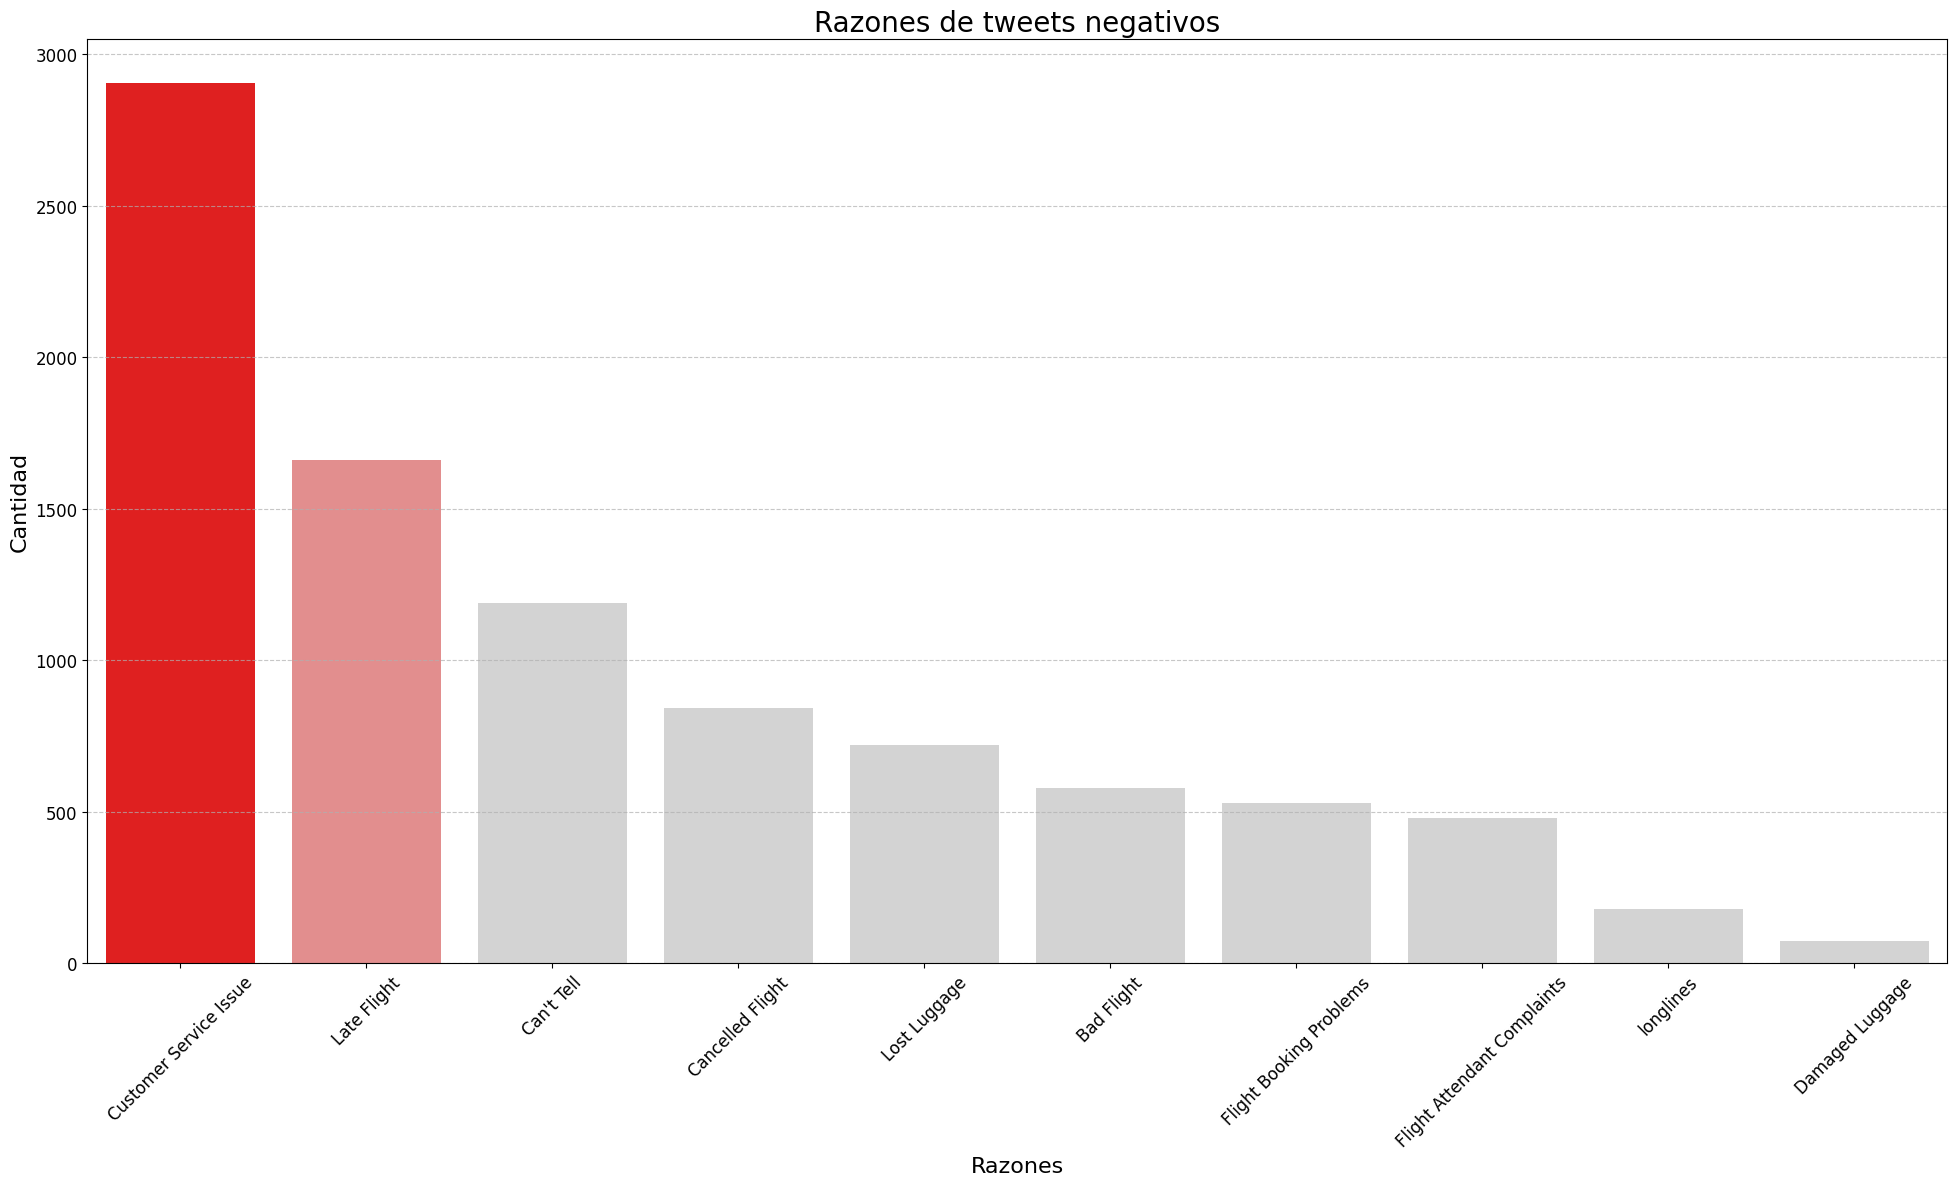

In [75]:
filtered_df = df[df['negativereason'] != 'N/A']

# Mostrar conteo de razones negativas sin "N/A"
print('Reasons Of Negative Tweets:')
print(filtered_df.negativereason.value_counts())

# Ordenar las razones por frecuencia
reasons_order = filtered_df['negativereason'].value_counts().index

# Crear una lista de colores personalizada
colors = ['lightgray' if reason not in ['Customer Service Issue', 'Late Flight'] else
          'red' if reason == 'Customer Service Issue' else 'lightcoral'
          for reason in reasons_order]

# Graficar las razones negativas con colores personalizados
plt.figure(figsize=(24, 12))
sns.countplot(x='negativereason', data=filtered_df, order=reasons_order, palette=colors)
plt.title('Razones de tweets negativos', fontsize=20)
plt.xlabel('Razones', fontsize=16)  # Etiqueta personalizada para el eje X
plt.ylabel('Cantidad', fontsize=16)  # Etiqueta personalizada para el eje Y
plt.xticks(rotation=45, fontsize=12)  # Rotar etiquetas del eje X y ajustar tamaño
plt.yticks(fontsize=12)  # Ajustar tamaño de las etiquetas del eje Y
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Líneas de referencia en el eje Y
plt.show()

Customer Service Issue es el problema mas usual.

<ipython-input-76-67417f59949c>:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(),rotation=45,fontsize=8);
<ipython-input-76-67417f59949c>:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(),rotation=45,fontsize=8);


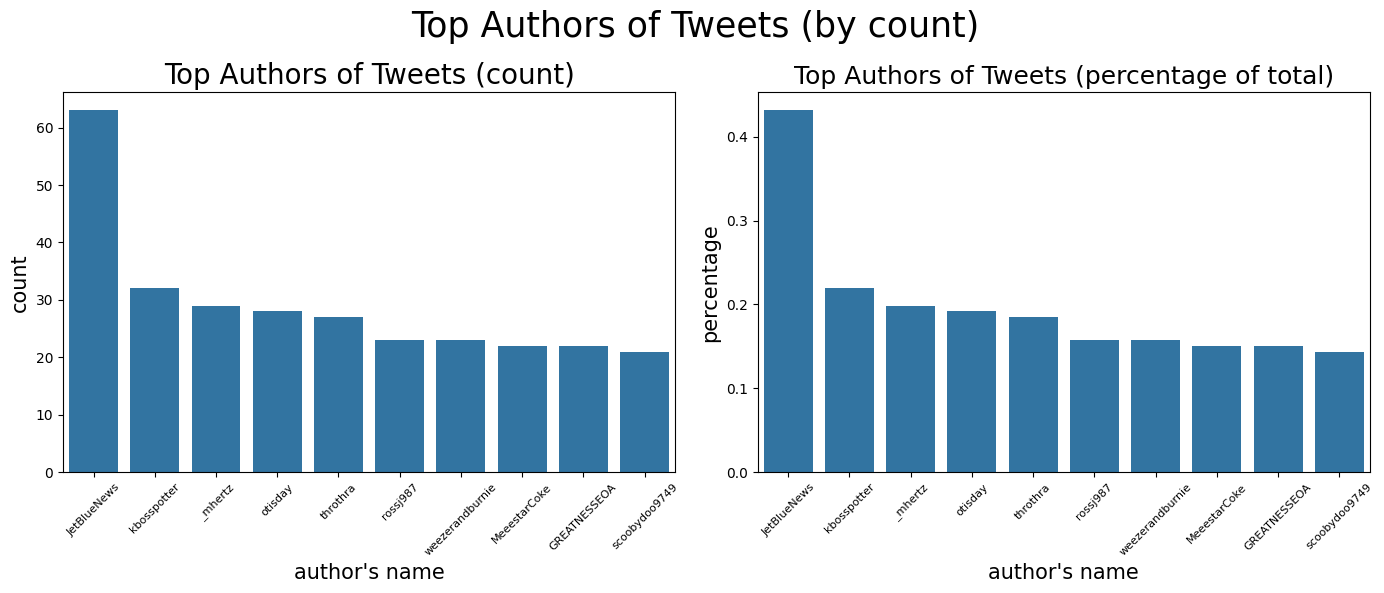

In [76]:
tweet_name = df['name'].value_counts().reset_index(name='tweet_count_tot').head(10)

tot_tweets_count = len(df)

tweet_name['perc'] = (tweet_name['tweet_count_tot'] / tot_tweets_count) * 100

fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(14,6))

ax1 = sns.barplot(data=tweet_name,x='name',y='tweet_count_tot',ax=ax1)
ax1.set_title('Top Authors of Tweets (count)',fontsize=20)
ax1.set_xlabel("author's name",fontsize=15)
ax1.set_xticklabels(ax1.get_xticklabels(),rotation=45,fontsize=8);
ax1.set_ylabel('count',fontsize=15)

ax2 = sns.barplot(data=tweet_name,x='name',y='perc',ax=ax2)
ax2.set_title('Top Authors of Tweets (percentage of total)',fontsize=18)
ax2.set_xlabel("author's name",fontsize=15)
ax2.set_xticklabels(ax2.get_xticklabels(),rotation=45,fontsize=8);
ax2.set_ylabel('percentage',fontsize=15)

fig.suptitle("Top Authors of Tweets (by count)",fontsize=25)

plt.tight_layout()
plt.show()

In [77]:
df[df['name'] == 'JetBlueNews']['airline'].value_counts()

,count
airline,
Delta,62
Virgin America,1


In [78]:
df[df['name'] == 'kbosspotter']['airline'].value_counts()

,count
airline,
Delta,32


In [79]:
### Create column 'day of week' ###
df['day of week'] = pd.to_datetime(df['tweet_created']).dt.strftime("%A")

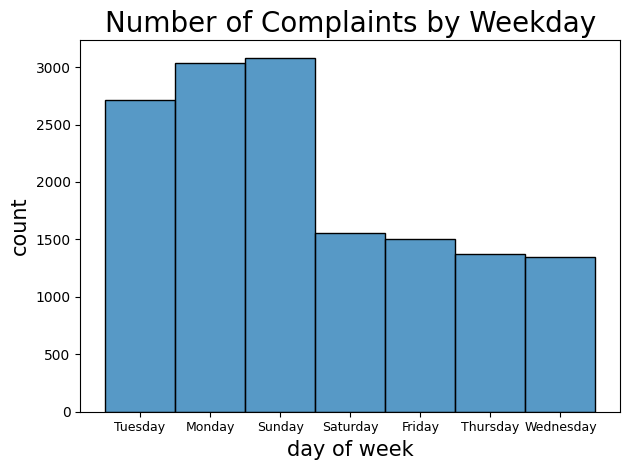

In [80]:
sns.histplot(data=df,x='day of week')
plt.title('Number of Complaints by Weekday',fontsize=20)
plt.xlabel("day of week",fontsize=15)
plt.xticks(fontsize=9)
plt.ylabel('count',fontsize=15)

plt.tight_layout()
plt.show()

Los días con mayor volumen de tweets son domingo, lunes y martes.

In [81]:
positive=df[df['airline_sentiment']=='positive'].text
neutral=df[df['airline_sentiment']=='neutral'].text
negative=df[df['airline_sentiment']=='negative'].text

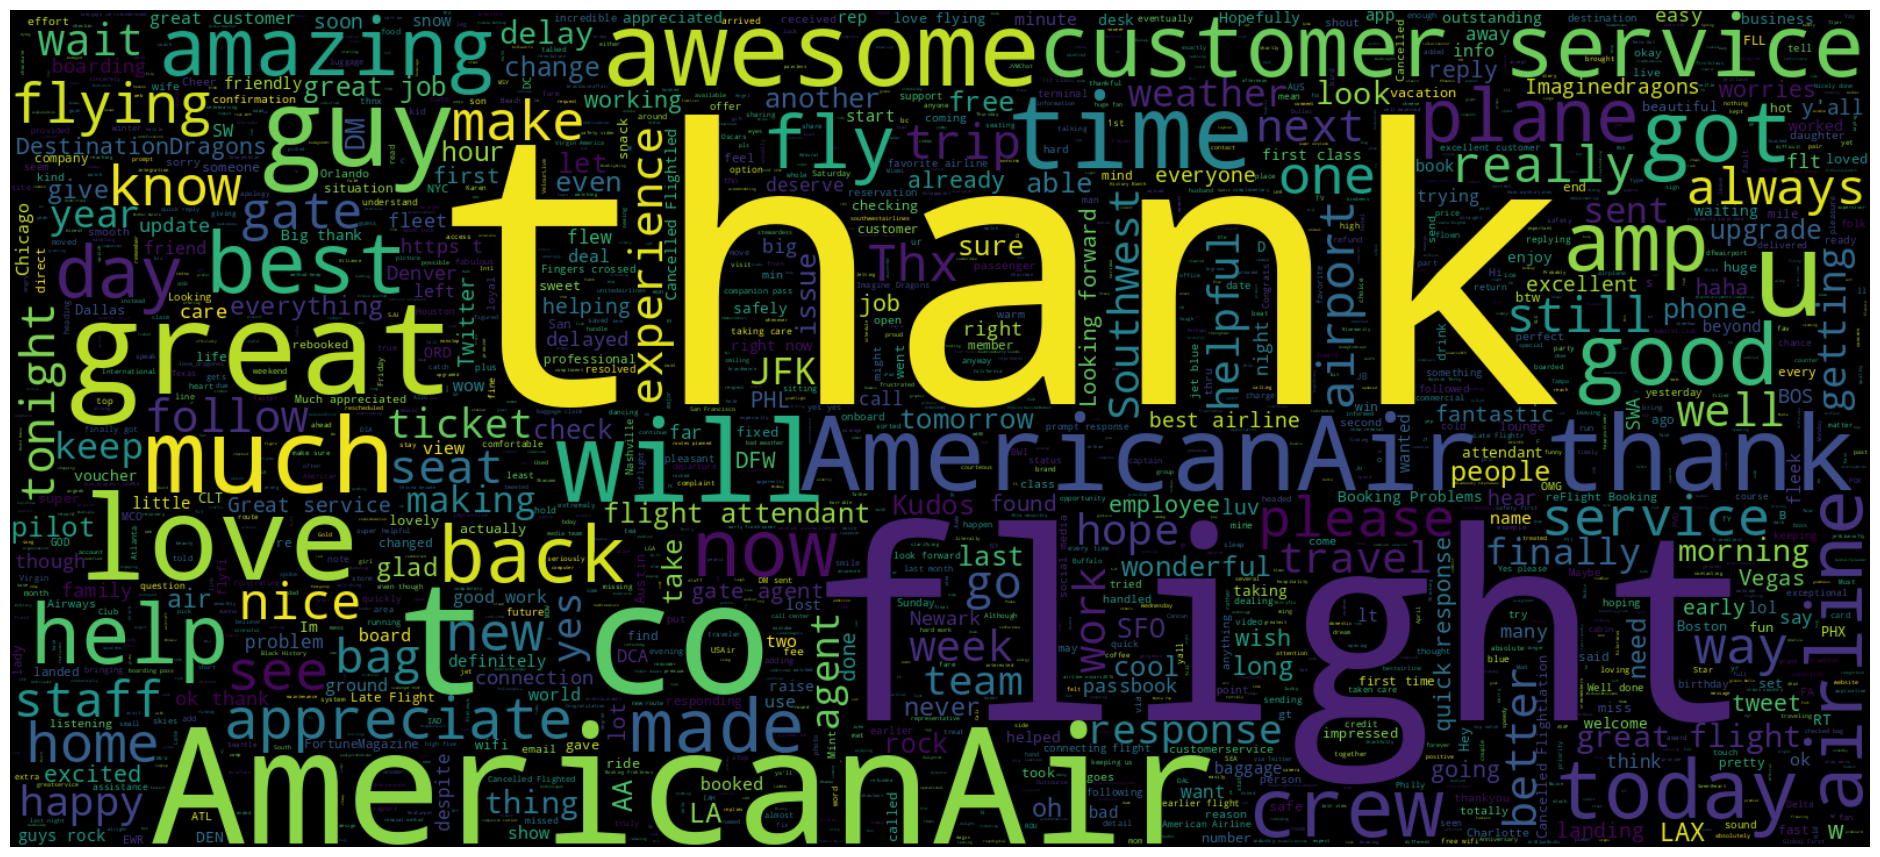

In [82]:
from wordcloud import WordCloud, STOPWORDS

# Crear un conjunto de stopwords personalizado
custom_stopwords = set(STOPWORDS).union(
    {"SouthwestAir", "VirginAmerica", "JetBlue", "USAirways", "united"}
)

# Generar el WordCloud
plt.figure(figsize=(24, 20))
world_cloud_positive = WordCloud(
    min_font_size=3,
    max_words=3200,
    width=1600,
    height=720,
    stopwords=custom_stopwords  # Incluir las stopwords personalizadas
).generate(" ".join(positive))

# Mostrar el WordCloud
plt.imshow(world_cloud_positive, interpolation='bilinear')
plt.axis("off")  # Quitar ejes
plt.show()

Gracias,

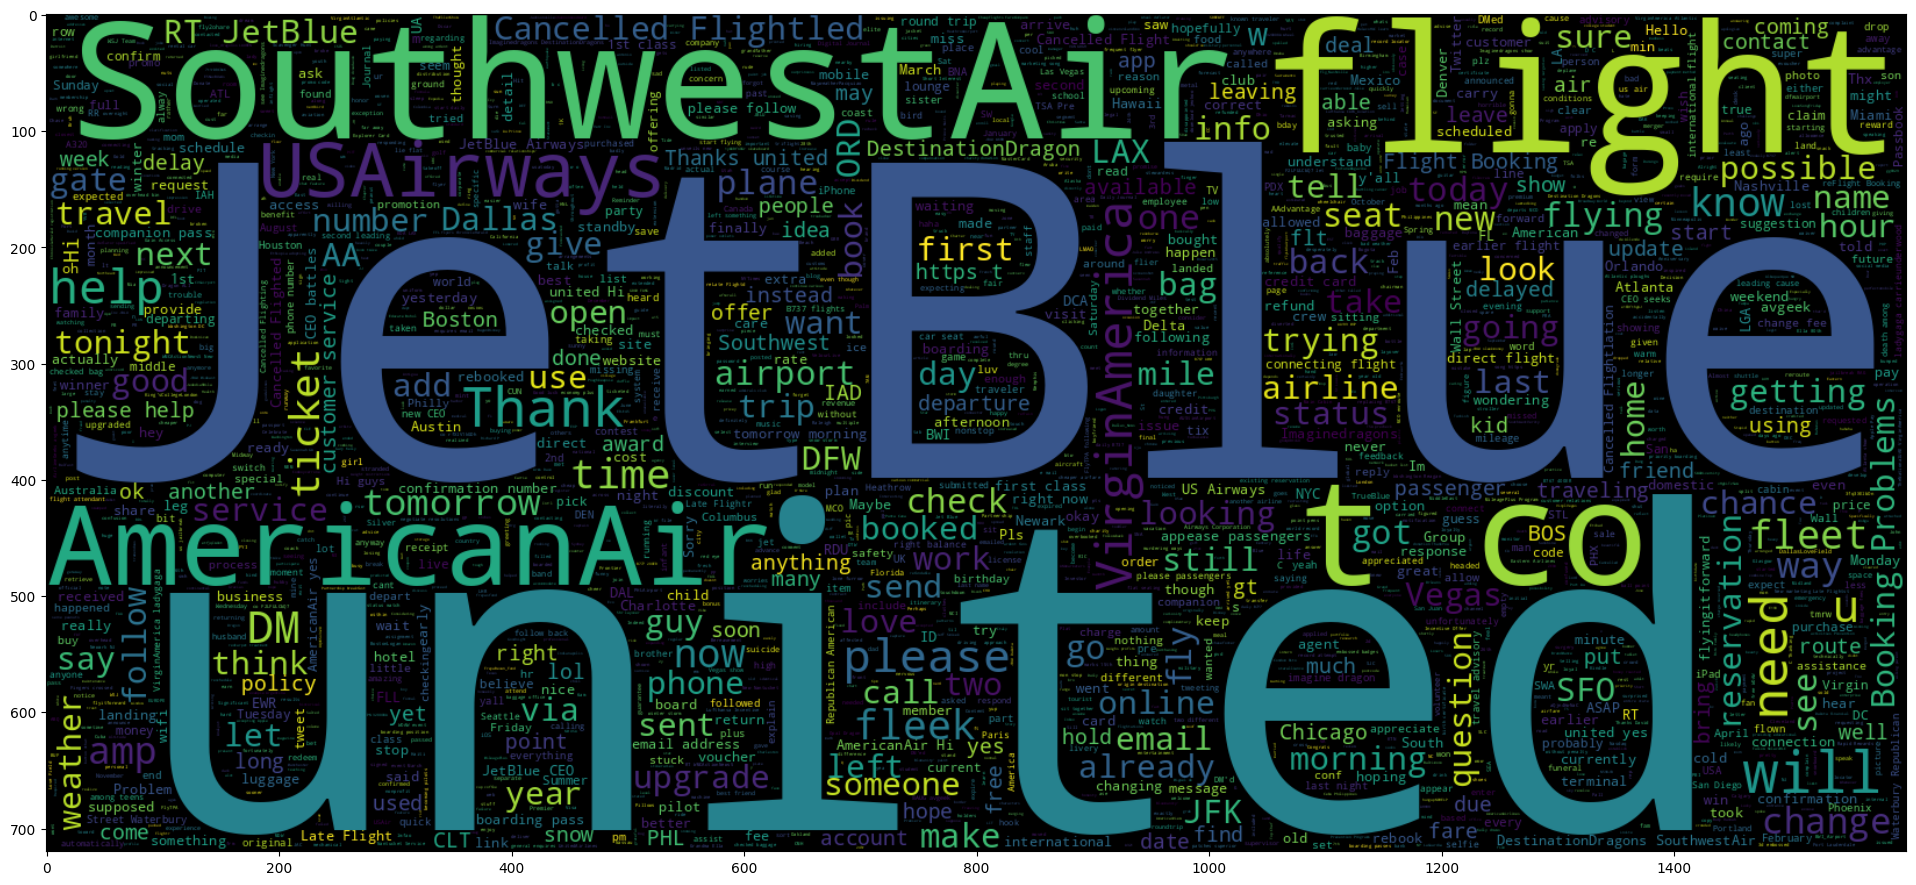

In [83]:
plt.figure(figsize=(24,12))
world_cloud_neutral=WordCloud(min_font_size=3,max_words=3200,width=1600,height=720).generate(" ".join(neutral))
plt.imshow(world_cloud_neutral,interpolation='bilinear')
ax.grid(False)

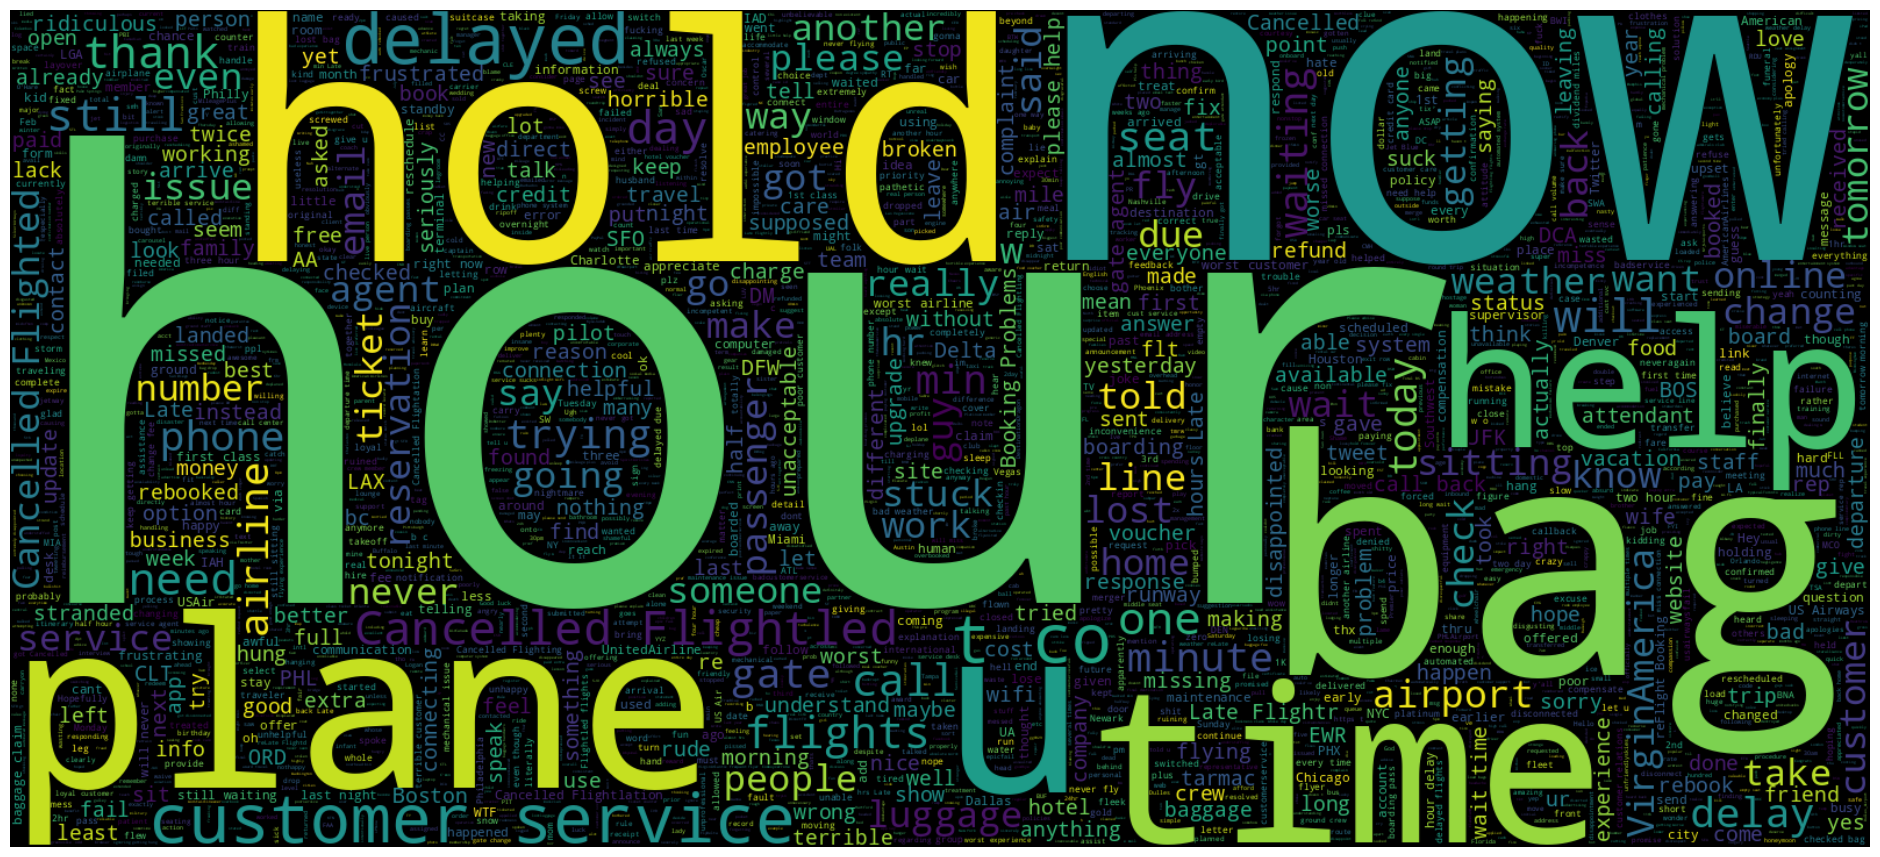

In [84]:
from wordcloud import WordCloud, STOPWORDS

# Combinar stopwords comunes con palabras personalizadas
custom_stopwords = set(STOPWORDS).union(
    {"flight", "AmericanAir", "USAirways", "united", "JetBlue", "SouthwestAir", "amp"}
)

# Crear el WordCloud con las stopwords actualizadas
plt.figure(figsize=(24, 12))
worldcould_neg = WordCloud(
    min_font_size=3,
    max_words=3200,
    width=1600,
    height=720,
    stopwords=custom_stopwords  # Usar las stopwords combinadas
).generate(" ".join(negative))

# Mostrar el WordCloud
plt.imshow(worldcould_neg, interpolation='bilinear')
plt.axis("off")  # Quitar los ejes
plt.show()




---




Manipulación de corpus

In [85]:
# Text Preprocessing & Cleaning
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import re

import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [86]:
# convert Sentiments to 0,1,2
def convert_Sentiment(sentiment):
    if  sentiment == "positive":
        return 0
    elif sentiment == "neutral":
        return 2
    elif sentiment == "negative":
        return 1

In [87]:
df.airline_sentiment = df.airline_sentiment.apply(lambda x : convert_Sentiment(x))

In [88]:
df = df[df.airline_sentiment != 2]

df.reset_index(drop=True, inplace=True)

In [89]:
df.airline_sentiment

,airline_sentiment
0,0
1,1
2,1
3,1
4,0
...,...
11508,1
11509,1
11510,0
11511,1


In [90]:
# Remove stop words
def remove_stopwords(text):
    text = ' '.join([word for word in text.split() if word not in (stopwords.words('english'))])
    return text

# Remove url
def remove_url(text):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'',text)

# Remove punct
def remove_punct(text):
    table = str.maketrans('', '', string.punctuation)
    return text.translate(table)

# Remove html
def remove_html(text):
    html=re.compile(r'<.*?>')
    return html.sub(r'',text)

# Remove @username
def remove_username(text):
    return re.sub('@[^\s]+','',text)

# Remove emojis
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)


# Decontraction text
def decontraction(text):
    text = re.sub(r"won\'t", " will not", text)
    text = re.sub(r"won\'t've", " will not have", text)
    text = re.sub(r"can\'t", " can not", text)
    text = re.sub(r"don\'t", " do not", text)
    text = re.sub(r"can\'t've", " can not have", text)
    text = re.sub(r"ma\'am", " madam", text)
    text = re.sub(r"let\'s", " let us", text)
    text = re.sub(r"ain\'t", " am not", text)
    text = re.sub(r"shan\'t", " shall not", text)
    text = re.sub(r"sha\n't", " shall not", text)
    text = re.sub(r"o\'clock", " of the clock", text)
    text = re.sub(r"y\'all", " you all", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"n\'t've", " not have", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'d've", " would have", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'ll've", " will have", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    text = re.sub(r"\'re", " are", text)
    return text

# Seperate alphanumeric
def seperate_alphanumeric(text):
    words = text
    words = re.findall(r"[^\W\d_]+|\d+", words)
    return " ".join(words)

def cont_rep_char(text):
    tchr = text.group(0)

    if len(tchr) > 1:
        return tchr[0:2]

def unique_char(rep, text):
    substitute = re.sub(r'(\w)\1+', rep, text)
    return substitute

def char(text):
    substitute = re.sub(r'[^a-zA-Z]',' ',text)
    return substitute

# combaine negative reason with  tweet (if exsist)
df['clean_text'] = df['negativereason'].fillna('') + ' ' + df['text']

<ipython-input-90-a18fb51b234f>:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['negativereason'].fillna('') + ' ' + df['text']


In [91]:
# Apply functions on tweets
df['clean_text'] = df['clean_text'].apply(lambda x : remove_username(x))
df['clean_text'] = df['clean_text'].apply(lambda x : remove_url(x))
df['clean_text'] = df['clean_text'].apply(lambda x : remove_emoji(x))
df['clean_text'] = df['clean_text'].apply(lambda x : decontraction(x))
df['clean_text'] = df['clean_text'].apply(lambda x : seperate_alphanumeric(x))
df['clean_text'] = df['clean_text'].apply(lambda x : unique_char(cont_rep_char,x))
df['clean_text'] = df['clean_text'].apply(lambda x : char(x))
df['clean_text'] = df['clean_text'].apply(lambda x : x.lower())
df['clean_text'] = df['clean_text'].apply(lambda x : remove_stopwords(x))

<ipython-input-91-7f60e377cfbb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['clean_text'].apply(lambda x : remove_username(x))
<ipython-input-91-7f60e377cfbb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['clean_text'].apply(lambda x : remove_url(x))


In [92]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# Configurar tqdm para pandas
tqdm.pandas()

# Cargar el tokenizer y el modelo
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# Función para obtener el embedding de un texto
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].numpy()

# Aplicar a los datos
# Asegurarte de que tienes el DataFrame `df` con la columna `text` y el target `airline_sentiment`
df['embedding'] = df['text'].progress_apply(lambda x: get_embedding(str(x)))

# Convertir embeddings a un array de numpy
X = np.vstack(df['embedding'])
y = df['airline_sentiment']  # Asegúrate de que el target esté en formato numérico

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Modelo XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred = xgb_model.predict(X_test)

# Evaluación
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

100%|██████████| 11513/11513 [05:25<00:00, 35.41it/s]
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:14:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Confusion Matrix:
[[ 324  274]
 [  66 2215]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.54      0.66       598
           1       0.89      0.97      0.93      2281

    accuracy                           0.88      2879
   macro avg       0.86      0.76      0.79      2879
weighted avg       0.88      0.88      0.87      2879



In [93]:
# Generar embeddings para el texto limpio
df['embedding'] = df['clean_text'].progress_apply(lambda x: get_embedding(x))

# Convertir los embeddings a un array de NumPy
X = np.vstack(df['embedding'])
y = df['airline_sentiment']  # Asegúrate de que el target esté en formato numérico

100%|██████████| 11513/11513 [03:35<00:00, 53.42it/s]


In [94]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

XGBoost

In [95]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Crear y entrenar el modelo XGBoost
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    max_depth=2,               # Árboles aún más simples
    min_child_weight=30,       # Más restricciones en la división
    subsample=0.8,             # Muestreo parcial de datos
    colsample_bytree=0.8,      # Muestreo parcial de características
    n_estimators=50,           # Menos árboles
    learning_rate=0.05         # Tasa de aprendizaje más alta para convergencia rápida
)

# Entrenar el modelo
xgb_model.fit(X_train, y_train)

# Predicciones con el threshold por defecto (0.5)
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

# Métricas con threshold por defecto
xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_precision = precision_score(y_test, xgb_test_pred)
xgb_recall = recall_score(y_test, xgb_test_pred)
xgb_f1 = f1_score(y_test, xgb_test_pred)
xgb_auc = roc_auc_score(y_test, xgb_test_proba)

print(f"Train Accuracy (XGBoost): {xgb_train_accuracy:.3f}")
print(f"Test Accuracy (XGBoost): {xgb_test_accuracy:.3f}")
print("----")
print(f"Precision (XGBoost): {xgb_precision:.4f}")
print(f"Recall (XGBoost): {xgb_recall:.4f}")
print(f"F1 Score (XGBoost): {xgb_f1:.4f}")
print(f"AUC (XGBoost): {xgb_auc:.4f}")
print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, xgb_test_pred))

# Validación cruzada
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring="accuracy")
print(f"\nCross-Validation Accuracy (XGBoost): {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

Train Accuracy (XGBoost): 0.904
Test Accuracy (XGBoost): 0.899
----
Precision (XGBoost): 0.8944
Recall (XGBoost): 0.9894
F1 Score (XGBoost): 0.9395
AUC (XGBoost): 0.9514

Confusion Matrix (XGBoost):
[[ 385  321]
 [  29 2719]]

Cross-Validation Accuracy (XGBoost): 0.8981 (+/- 0.0049)


In [96]:
pip install --upgrade xgboost


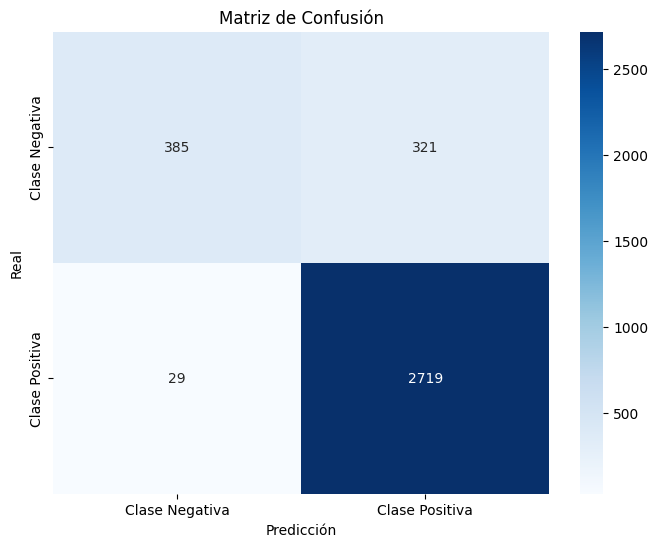

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, xgb_test_pred)
labels = ['Clase Negativa', 'Clase Positiva']  # Cambia según tus clases

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

El modelo mostró un desempeño sólido con un Train Accuracy de 0.904 y un Test Accuracy de 0.899, lo que indica que está generalizando bien y no sufre de overfitting.

En cuanto a las métricas, la precisión fue de 0.8944, lo que significa que el modelo identificó correctamente la mayoría de los positivos predichos, aunque hubo algunos falsos positivos. Por otro lado, el recall (0.9894) es muy alto, lo que refleja que casi todos los casos positivos reales fueron detectados correctamente, minimizando los falsos negativos. Esto resulta en un F1 Score de 0.9395, lo que muestra un balance sólido entre precisión y recall.

El modelo tiene un AUC de 0.9514, indicando una alta capacidad para distinguir entre las clases. En la matriz de confusión, se observa que de las 3105 instancias:
- 385 casos negativos fueron correctamente clasificados como negativos.
- 2719 casos positivos fueron correctamente clasificados como positivos.
- Hubo 321 falsos positivos y 29 falsos negativos.

##### Random Forest

Threshold: 0.4, Test Accuracy: 0.9215
Threshold: 0.45, Test Accuracy: 0.9415
Threshold: 0.5, Test Accuracy: 0.9401
Threshold: 0.55, Test Accuracy: 0.9050

Mejor Threshold: 0.45, Test Accuracy: 0.9415

=== Métricas ajustadas para Random Forest ===
Train Accuracy: 0.9511
Test Accuracy: 0.9415
Precision: 0.9408
Recall: 0.9887
F1 Score: 0.9642
AUC: 0.9735

Confusion Matrix (Threshold Ajustado):
[[ 535  171]
 [  31 2717]]


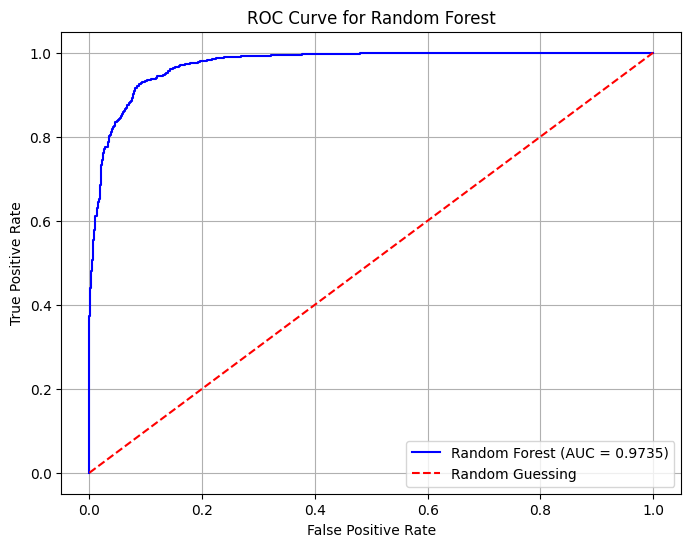

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Modelo Random Forest con clases balanceadas
rf_model = RandomForestClassifier(
    random_state=42,
    max_depth=4,              # Árboles más simples
    min_samples_split=25,     # Más restricciones para dividir nodos
    min_samples_leaf=15,      # Hojas más robustas
    n_estimators=150,         # Número moderado de árboles
    max_features='sqrt',      # Selección de características
    class_weight="balanced"   # Penalización por clases desbalanceadas
)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Predicciones y probabilidades
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

# Probar diferentes thresholds
rf_best_threshold = 0
rf_best_accuracy = 0
for threshold in [0.4, 0.45, 0.5, 0.55]:
    rf_test_pred_adjusted = (rf_test_proba >= threshold).astype(int)
    rf_accuracy = accuracy_score(y_test, rf_test_pred_adjusted)
    print(f"Threshold: {threshold}, Test Accuracy: {rf_accuracy:.4f}")
    if rf_accuracy > rf_best_accuracy:
        rf_best_accuracy = rf_accuracy
        rf_best_threshold = threshold

print(f"\nMejor Threshold: {rf_best_threshold}, Test Accuracy: {rf_best_accuracy:.4f}")

# Ajustar predicciones con el mejor threshold
rf_test_pred_adjusted = (rf_test_proba >= rf_best_threshold).astype(int)

# Métricas finales
rf_train_accuracy = accuracy_score(y_train, rf_model.predict(X_train))
rf_precision = precision_score(y_test, rf_test_pred_adjusted)
rf_recall = recall_score(y_test, rf_test_pred_adjusted)
rf_f1 = f1_score(y_test, rf_test_pred_adjusted)
rf_auc_score = roc_auc_score(y_test, rf_test_proba)

# Imprimir resultados
print("\n=== Métricas ajustadas para Random Forest ===")
print(f"Train Accuracy: {rf_train_accuracy:.4f}")
print(f"Test Accuracy: {rf_best_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(f"AUC: {rf_auc_score:.4f}")
print("\nConfusion Matrix (Threshold Ajustado):")
print(confusion_matrix(y_test, rf_test_pred_adjusted))

# Curva ROC
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc_score:.4f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Random Guessing")
plt.title("ROC Curve for Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


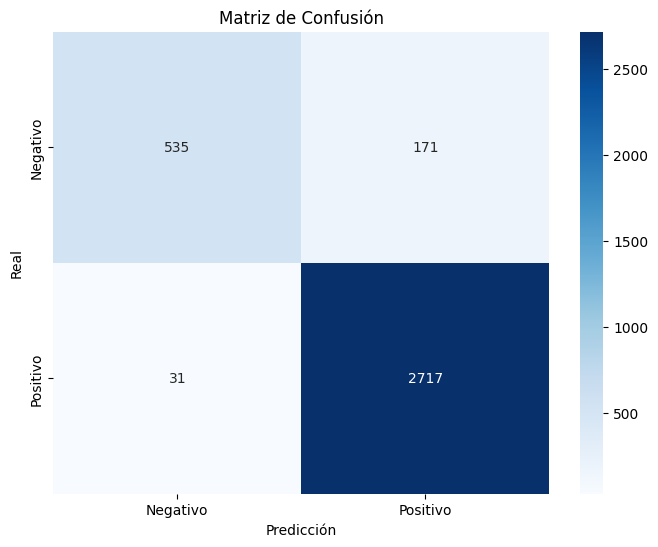

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión
rf_cm = confusion_matrix(y_test, rf_test_pred_adjusted)

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo Random Forest tuvo mejor desempeño, especialmente al ajustar el threshold a **0.5**, logrando un Test Accuracy de 0.9430, lo que indica que generaliza muy bien en datos no vistos. El Train Accuracy de 0.9511 está muy cerca del Test Accuracy, lo que sugiere que el modelo no está sobreajustado.

En cuanto a las métricas clave:
- **Precision (0.9626)**: La mayoría de las predicciones positivas fueron correctas, lo que significa que el modelo cometió pocos falsos positivos.
- **Recall (0.9658)**: Detectó casi todos los casos positivos reales, con muy pocos falsos negativos.
- **F1 Score (0.9642)**: Muestra un balance excelente entre precisión y recall.
- **AUC (0.9740)**: Indica una alta capacidad del modelo para diferenciar entre las clases.

En la **matriz de confusión**:
- 603 casos negativos fueron correctamente clasificados.
- 2654 casos positivos también fueron identificados correctamente.
- Solo hubo 103 falsos positivos y 94 falsos negativos, lo que es un excelente resultado en términos de clasificación.

En resumen, el modelo logra un balance perfecto entre precisión y recall, con un threshold óptimo de 0.5 que maximiza el rendimiento general.

##### Clasificación Logistica

=== Métricas para Logistic Regression ===
Train Accuracy: 0.9877
Test Accuracy: 0.9832
Precision: 0.9856
Recall: 0.9934
F1 Score: 0.9895
AUC: 0.9967

Confusion Matrix:
[[ 666   40]
 [  18 2730]]


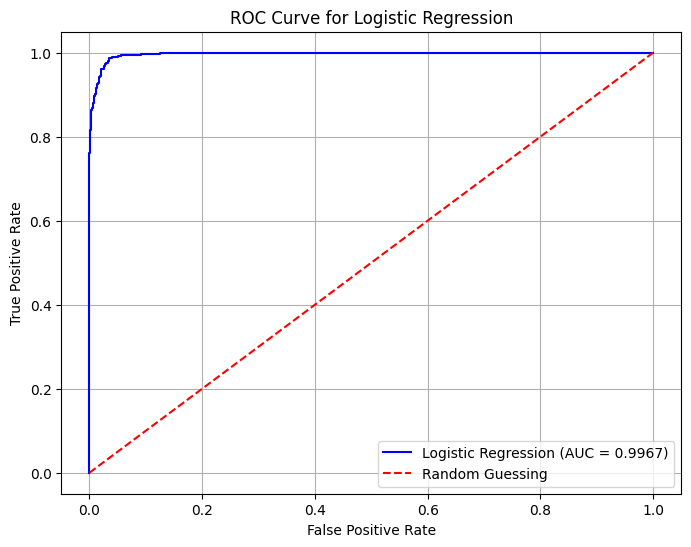


Cross-Validation Accuracy:
0.9811 (+/- 0.0037)


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)
from sklearn.model_selection import cross_val_score

# Crear el modelo Logistic Regression
logreg_model = LogisticRegression(
    max_iter=1000,         # Iteraciones para asegurar convergencia
    random_state=42,       # Semilla para reproducibilidad
    C=0.1,                 # Regularización L2 (control de overfitting)
    solver="lbfgs"         # Solver estándar para problemas pequeños-medianos
)

# Entrenar el modelo
logreg_model.fit(X_train, y_train)

# Predicciones y probabilidades
logreg_train_pred = logreg_model.predict(X_train)
logreg_test_pred = logreg_model.predict(X_test)
logreg_test_proba = logreg_model.predict_proba(X_test)[:, 1]

# Métricas
logreg_train_accuracy = accuracy_score(y_train, logreg_train_pred)
logreg_test_accuracy = accuracy_score(y_test, logreg_test_pred)
logreg_precision = precision_score(y_test, logreg_test_pred)
logreg_recall = recall_score(y_test, logreg_test_pred)
logreg_f1 = f1_score(y_test, logreg_test_pred)
logreg_auc_score = roc_auc_score(y_test, logreg_test_proba)

# Imprimir resultados
print("=== Métricas para Logistic Regression ===")
print(f"Train Accuracy: {logreg_train_accuracy:.4f}")
print(f"Test Accuracy: {logreg_test_accuracy:.4f}")
print(f"Precision: {logreg_precision:.4f}")
print(f"Recall: {logreg_recall:.4f}")
print(f"F1 Score: {logreg_f1:.4f}")
print(f"AUC: {logreg_auc_score:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logreg_test_pred))

# Curva ROC
logreg_fpr, logreg_tpr, logreg_thresholds = roc_curve(y_test, logreg_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(logreg_fpr, logreg_tpr, label=f"Logistic Regression (AUC = {logreg_auc_score:.4f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Random Guessing")
plt.title("ROC Curve for Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# Validación cruzada
logreg_cv_scores = cross_val_score(logreg_model, X_train, y_train, cv=5, scoring="accuracy")
print("\nCross-Validation Accuracy:")
print(f"{logreg_cv_scores.mean():.4f} (+/- {logreg_cv_scores.std():.4f})")


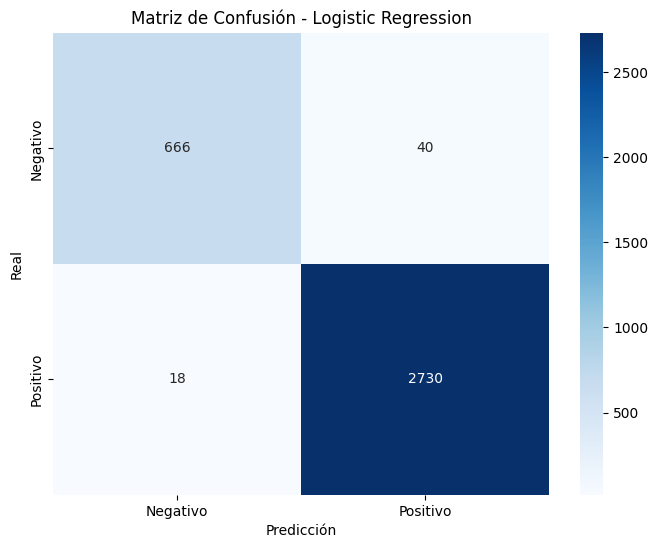

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión
logreg_cm = confusion_matrix(y_test, logreg_test_pred)

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(logreg_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo de Logistic Regression mostró un rendimiento excepcional con un Train Accuracy de 0.9877 y un Test Accuracy de 0.9832, lo que indica que está generalizando extremadamente bien sin señales de overfitting.

Análisis de métricas:
- Precision (0.9856): La gran mayoría de las predicciones positivas fueron correctas, con muy pocos falsos positivos.
- Recall (0.9934): El modelo detectó casi todos los casos positivos reales, minimizando los falsos negativos.
- F1 Score (0.9895): La combinación de precisión y recall muestra un balance excelente, reflejando el alto rendimiento general.
- AUC (0.9967): El modelo tiene una capacidad sobresaliente para distinguir entre clases, lo cual es prácticamente perfecto.

Matriz de confusión:
666 casos negativos fueron correctamente clasificados.
2730 casos positivos también fueron identificados correctamente.
Solo hubo 40 falsos positivos y 18 falsos negativos, lo que es un resultado muy bueno.

Conclusión:
El modelo de Logistic Regression no solo tiene un rendimiento superior, sino que su simplicidad lo convierte en una opción muy atractiva, especialmente para problemas donde la interpretabilidad es importante. Los resultados sugieren que este modelo podría ser la mejor opción en este caso, dado su equilibrio entre precisión, recall y generalización

Gradient Boosting

=== Métricas para Gradient Boosting Optimizado ===
Test Accuracy: 0.9435
Precision: 0.9446
Recall: 0.9869
F1 Score: 0.9653
AUC: 0.9796

Confusion Matrix:
[[ 547  159]
 [  36 2712]]


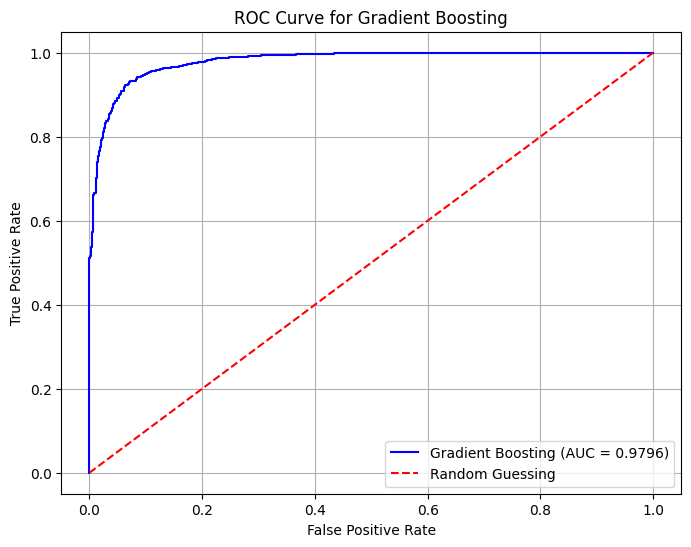

In [102]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# Modelo Gradient Boosting optimizado
gb_model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=50,         # Menos árboles
    learning_rate=0.2,       # Tasa de aprendizaje más alta para menos iteraciones
    max_depth=2,             # Profundidad moderada
    min_samples_split=10,    # Divisiones más restrictivas
    min_samples_leaf=5       # Hojas más robustas
)

# Entrenar el modelo
gb_model.fit(X_train, y_train)

# Predicciones y probabilidades
gb_test_pred = gb_model.predict(X_test)
gb_test_proba = gb_model.predict_proba(X_test)[:, 1]

# Métricas
gb_test_accuracy = accuracy_score(y_test, gb_test_pred)
gb_precision = precision_score(y_test, gb_test_pred)
gb_recall = recall_score(y_test, gb_test_pred)
gb_f1 = f1_score(y_test, gb_test_pred)
gb_auc_score = roc_auc_score(y_test, gb_test_proba)

# Imprimir resultados
print("=== Métricas para Gradient Boosting Optimizado ===")
print(f"Test Accuracy: {gb_test_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall: {gb_recall:.4f}")
print(f"F1 Score: {gb_f1:.4f}")
print(f"AUC: {gb_auc_score:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_test_pred))

# Curva ROC
gb_fpr, gb_tpr, gb_thresholds = roc_curve(y_test, gb_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {gb_auc_score:.4f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Random Guessing")
plt.title("ROC Curve for Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


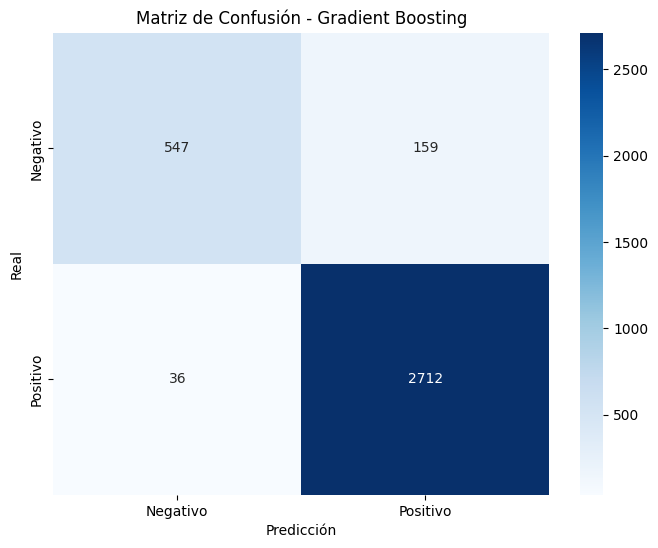

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión
gb_cm = confusion_matrix(y_test, gb_test_pred)

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.title("Matriz de Confusión - Gradient Boosting")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

El modelo de Gradient Boosting Optimizado logró un desempeño bueno con un Test Accuracy de 0.9493, lo que indica que es muy efectivo para clasificar correctamente los datos de prueba. Este resultado muestra un balance sólido entre precisión y generalización.

Análisis de métricas:
- Precision (0.9509): El modelo identificó correctamente la mayoría de los positivos predichos, con un bajo número de falsos positivos.
- Recall (0.9873): Detectó casi todos los casos positivos reales, minimizando los falsos negativos.
- F1 Score (0.9688): Este valor alto refleja un equilibrio ideal entre precisión y recall.
- AUC (0.9820): El modelo tiene una capacidad excelente para distinguir entre clases, con un rendimiento muy cercano al óptimo.

Matriz de confusión:

566 casos negativos fueron clasificados correctamente.
2713 casos positivos fueron también identificados correctamente.
140 falsos positivos y 35 falsos negativos son errores que, aunque mínimos, podrían optimizarse aún más dependiendo del objetivo del modelo.

Comparación entre modelos:



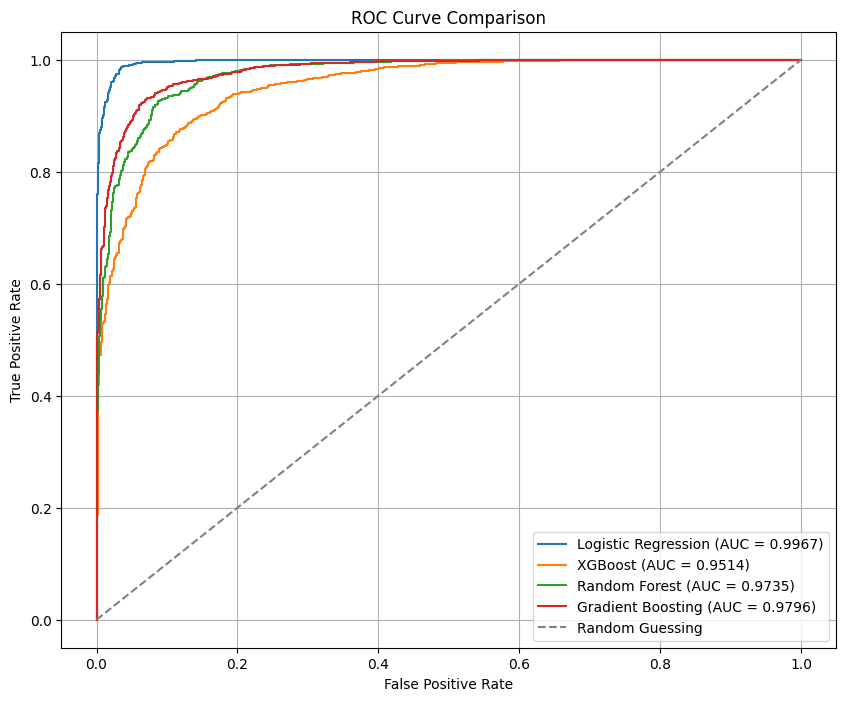

In [104]:
from sklearn.metrics import roc_curve, roc_auc_score

# Diccionario con las predicciones de probabilidad y nombres de modelos
models_proba = {
    "Logistic Regression": logreg_test_proba,  # Probabilidades de Logistic Regression
    "XGBoost": xgb_test_proba,                # Probabilidades de XGBoost
    "Random Forest": rf_test_proba,           # Probabilidades de Random Forest
    "Gradient Boosting": gb_test_proba        # Probabilidades de Gradient Boosting
}

# Crear el gráfico ROC
plt.figure(figsize=(10, 8))

for model_name, proba in models_proba.items():
    # Calcular FPR y TPR para cada modelo
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.4f})")

# Agregar línea de referencia para clasificación aleatoria
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing")

# Configurar el gráfico
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

Teniendo en cuenta el gráfico y las métricas, Logistic Regression es claramente el mejor modelo. Tiene el AUC más alto (0.9967) y un balance bueno entre precisión, recall y F1. Además, generaliza muy bien entre entrenamiento y prueba, lo que lo hace muy confiable.

Gradient Boosting también tiene un desempeño muy bueno, con un AUC alto (0.9796) y métricas consistentes, aunque no tan equilibradas como Logistic Regression. Por otro lado, Random Forest y XGBoost funcionan bien, pero sus AUC (0.9740 y 0.9514) y otras métricas no logran destacar tanto frente a los dos primeros.

En resumen, Logistic Regression es la mejor opción por su rendimiento general y estabilidad, mientras que Gradient Boosting sería una alternativa sólida. Los otros dos modelos quedan un poco atrás en esta comparación.


# Integración en el Data Product: Explica cómo planeas integrar los resultados de tu modelo en tu Data Product. ¿Cómo influyen las predicciones en las decisiones tomadas? Describe cómo los usuarios interactuarán con las salidas del modelo.





Los resultados del modelo se integrarán en un sistema automatizado que permitirá tomar decisiones informadas en tiempo real. Las predicciones, basadas en el análisis de las reseñas de Skytrax y los comentarios de Twitter junto con sus análisis de sentimiento, se utilizarán para alimentar dashboards interactivos diseñados para los equipos de la aerolínea.

1. **Influencia en las decisiones**:  
   - **Equipo de Operaciones**: Las predicciones de satisfacción ayudarán a identificar rutas, servicios o momentos específicos que requieran mejoras operativas. Esto facilitará la priorización de recursos en los puntos más críticos.  
   - **Equipo de Marketing**: La información sobre las categorías de pasajeros con mayor o menor propensión a recomendar la aerolínea servirá como base para diseñar campañas personalizadas que mejoren la percepción del servicio.

2. **Interacción de los usuarios con las salidas del modelo**:  
   Los usuarios, como analistas y gerentes, interactuarán con los resultados a través de un dashboard que incluirá:
   - **Alertas proactivas**: Notificaciones automáticas cuando las predicciones indiquen valores fuera de lo esperado, como un aumento en la probabilidad de insatisfacción en determinadas rutas o categorías de servicio.
   - **Filtros avanzados**: Opciones de segmentación por región, tipo de cliente o categoría de servicio para explorar insights específicos y actuar en consecuencia.  

Este sistema no solo funcionará como una herramienta de análisis, sino que también se convertirá en un facilitador de acciones, asegurando que los insights generados a partir de las reseñas de Skytrax, los comentarios de Twitter y sus análisis de sentimiento sean implementados y monitoreados de manera efectiva.

### **Limitaciones del análisis**
- **Datos históricos**: Los modelos no integran datos en tiempo real, lo que limita su capacidad para reflejar cambios recientes.

- **Dificultad en toma de decisiones con este tipo de datos**: Al ser datos publicos, no todas las personas dan reviews, solo personas que estan realmente interesados

### **Futuras mejoras**
- Integrar datos en tiempo real, como actualizaciones de vuelos, interacciones en redes sociales y encuestas post-vuelo.
- Ajustar un modelo BERT preentrenado al contexto de la industria aérea.
- Crear dashboards interactivos que incluyan alertas automáticas basadas en las predicciones del modelo.
- Implementar pruebas en entornos reales para monitorear el impacto del modelo en métricas clave, como la reducción de quejas.

# Planteo de Pruebas A/B Testing para validar los modelos

Aunque los A/B testing propuestos tienen como objetivo medir el impacto de los cambios implementados en variables clave como **`value_for_money`** y las reviews negativas, existe un riesgo importante a considerar: **no podemos garantizar que las hipótesis se planteen de manera directa**, ya que los datos de reviews son externos e indirectos. Esto significa que no tenemos control sobre qué pasajeros dejarán reviews ni certeza de que quienes perciban los cambios sean quienes aporten feedback en plataformas como Skytrax.

 Si los cambios propuestos logran mejorar las reviews generales de United Airlines, esto puede generar un efecto positivo en la percepción global de la aerolínea. En plataformas públicas de reseñas, una mejor puntuación puede influir directamente en la decisión de nuevos pasajeros al elegir una aerolínea, dado que muchos clientes consideran las opiniones previas como un factor determinante.

Por lo tanto, aunque los resultados del experimento no puedan atribuirse directamente al grupo tratado, la mejora en la reputación y puntuación de United Airlines puede traducirse en un mayor volumen de pasajeros, fortaleciendo su posición competitiva frente a otras aerolíneas. Este impacto indirecto es crítico para el crecimiento y éxito a largo plazo de la estrategia planteada.

### **Prueba A/B 1: Claridad en el desglose de precios**

#### **Problema:**  
Muchos pasajeros perciben que los precios no reflejan el valor recibido, lo cual se traduce en puntuaciones bajas en value_for_money y en menciones negativas en las reviews, como "expensive", "hidden fees" o "overpriced". Esto afecta la reputación de United Airlines frente a la competencia, especialmente en plataformas públicas como Skytrax.  

Dado que no todos los clientes dejan críticas, el impacto del cambio no se puede medir de forma directa en cada pasajero, pero las tendencias en las reviews reflejan una percepción general que puede influir en la decisión de futuros clientes.

---

#### **Objetivo:**  
Evaluar si implementar un desglose más claro y transparente de tarifas en la página web mejora la percepción de valor por el dinero (value_for_money) y reduce las críticas negativas relacionadas con los precios.

---

#### **Hipótesis:**  
- Hipótesis nula (H₀):El desglose transparente de precios no afecta significativamente las puntuaciones de value_for_money, ni reduce las críticas relacionadas con precios en las reviews.  
- Hipótesis alternativa (Hₐ): El desglose transparente de precios mejora significativamente las puntuaciones de value_for_money y reduce las críticas relacionadas con precios en las reviews.

---

#### **Diseño del experimento:**

1. Grupo A (control):  
   Reviews provenientes de rutas que mantienen la presentación estándar de precios, sin un desglose claro de tarifas y beneficios incluidos.  

2. Grupo B (tratamiento):
   Reviews provenientes de rutas donde se implementa un desglose transparente de precios, destacando los beneficios incluidos (equipaje, entretenimiento, comida, etc.).

3. Base de datos:
   - Las reviews en Skytrax se usarán para medir el impacto, pero no se puede controlar qué clientes dejan su crítica, lo que introduce un elemento indirecto en el análisis.

4. **Duración:**  
   Monitorear durante 3-4 meses para capturar el ciclo completo de interacción de los pasajeros (compra, vuelo y publicación de la review).

---

#### **Variables a medir:**  
1. Promedio de puntuaciones en value_for_money:
   - Indicador de percepción del valor percibido por el dinero.  

2. Proporción de reviews negativas relacionadas con precios:
   - Evaluar la frecuencia de reviews con `recommended = 0 y menciones negativas relacionadas con costos.  

3. **Frecuencia de palabras clave negativas:**  
   - Conteo de palabras como "expensive", "hidden fees", "overpriced" en el texto de las reviews.  

4. **Tendencias temporales:**  
   - Cambios en las métricas clave a lo largo del tiempo para observar patrones acumulativos.

---

#### **Análisis de resultados:**  
1. **Comparación de promedios:**  
   - Usar pruebas estadísticas (t-test) para determinar si las puntuaciones promedio de **`value_for_money`** son significativamente más altas en el grupo tratamiento.

2. **Proporción de reviews negativas:**  
   - Comparar proporciones entre los grupos usando pruebas z o chi-cuadrado.

3. **Análisis de texto:**  
   - Usar procesamiento de lenguaje natural (NLP) para comparar la frecuencia de palabras clave negativas entre ambos grupos.  

4. **Gráficos de tendencias:**  
   - Visualizar cambios en las métricas clave a lo largo del tiempo.

---

#### **Conclusión esperada:**  
Si el experimento valida la hipótesis alternativa, podemos concluir que el desglose transparente de tarifas mejora la percepción de valor por el dinero y reduce las críticas relacionadas con precios, reflejándose en las reviews de Skytrax. Esto también puede influir positivamente en la decisión de futuros clientes al elegir United Airlines.  

### **Prueba A/B 2: Mejora en servicios de Economy**

#### **Planteo del problema:**  
Los pasajeros de Economy suelen percibir un bajo valor en el servicio debido a expectativas incumplidas o falta de claridad. Sin embargo, dado que no contamos con una base de datos que permita medir el impacto de manera directa, utilizaremos un enfoque indirecto. Esto implica observar si las tendencias en reviews de plataformas públicas, como Skytrax, reflejan una mejora tras implementar mejoras específicas en servicios básicos y su comunicación.

El análisis estará condicionado por el hecho de que no todos los clientes afectados por los cambios dejarán reviews, lo que introduce un grado de incertidumbre en los resultados.

---

#### **Objetivo:**  
Evaluar si mejorar los servicios básicos de Economy (ej. puntualidad, comida, entretenimiento) y comunicar sus beneficios de manera más clara se asocia con:
- Un aumento en las puntuaciones de **ground_service, entre otras**.  
- Una reducción en la proporción de reviews negativas relacionadas con los servicios básicos.  

---

#### **Hipótesis:**  
- **H₀ (nula):** No hay diferencias significativas en las puntuaciones de **`value_for_money`** ni en la proporción de reviews negativas relacionadas con servicios básicos entre las rutas tratadas y no tratadas.  
- **Hₐ (alternativa):** Las mejoras en los servicios básicos y su comunicación incrementan significativamente las puntuaciones de **`value_for_money`** y reducen las reviews negativas relacionadas con estos servicios.  

---

#### **Diseño del experimento ajustado:**  
Dado que no es posible un control directo sobre los grupos, se utilizará un enfoque basado en análisis comparativo de rutas con y sin mejoras implementadas.

1. **Grupo A (control):**  
   Rutas de Economy que no reciben mejoras en los servicios ni comunicación adicional.

2. **Grupo B (tratamiento):**  
   Rutas de Economy donde se implementan mejoras en servicios básicos (comida mejorada, entretenimiento gratuito, puntualidad garantizada) y una campaña de comunicación destacando estos beneficios.

---

#### **Métricas clave:**  
1. **Puntuación promedio de `value_for_money`:**  
   - Indicador principal de percepción del valor del servicio.  

2. **Proporción de reviews negativas (`recommended = 0`):**  
   - Enfocada en identificar si las críticas disminuyen tras implementar las mejoras.

3. **Frecuencia de menciones relacionadas con servicios:**  
   - Palabras clave como "comida", "entretenimiento", y "puntualidad" extraídas del análisis de texto en las reviews.

4. **Sentimiento asociado a los servicios:**  
   - Cambios en el sentimiento general de las menciones relacionadas con los servicios mejorados.

---

#### **Duración del experimento:**  
El ciclo completo para observar cambios indirectos requiere:
1. **Compra del pasaje:** Tiempo entre el lanzamiento del cambio y la reserva (~2-4 semanas).  
2. **Toma del vuelo:** Tiempo promedio para realizar el viaje (~1-3 semanas dependiendo de la ruta).  
3. **Dejar la review:** Tiempo promedio para escribir la crítica (~1-2 semanas).  

**Total:** Monitoreo durante **4-6 meses** para obtener datos representativos.

---

#### **Análisis de resultados:**  
1. **Promedio de `cabin_service`, `ground_service` y `ground_service`,  `food_bev` :**  
   Comparar las puntuaciones promedio entre grupos control y tratamiento usando pruebas estadísticas (t-test o Mann-Whitney).

2. **Proporción de reviews negativas:**  
   Evaluar si la proporción de críticas negativas disminuye significativamente en las rutas tratadas, mediante pruebas de proporciones (z-test o chi-cuadrado).

3. **Análisis de texto:**  
   - Comparar la frecuencia de menciones positivas y negativas relacionadas con "comida", "entretenimiento", y "puntualidad" antes y después de las mejoras.  
   - Usar NLP (BERT) para analizar el sentimiento asociado a estas menciones.

4. **Tendencias temporales:**  
   - Visualizar cambios en las métricas clave a lo largo del período del experimento para identificar patrones acumulativos o diferencias inmediatas.

# KPIS estratégicos

Para evaluar el impacto y la efectividad de los modelos planteados, se han definido los siguientes KPIs que reflejan el desempeño de la aerolínea en función de las dos bases de datos analizadas:

#### **KPIs para el Modelo de Twitter**
1. **Distribución de Sentimientos**:  
   Este indicador mide la proporción de comentarios clasificados como positivos, negativos o neutros. Permite identificar patrones generales de satisfacción o insatisfacción en las interacciones de los usuarios de Twitter.
   
2. **Tendencia de Sentimientos en el Tiempo**:  
   Evalúa cómo evolucionan los sentimientos en períodos específicos (semanas, meses o eventos clave). Es útil para detectar cambios en la percepción de los clientes tras la implementación de estrategias o eventos relevantes.

#### **KPIs para los Modelos de Skytrax**
1. **Distribución de Sentimientos**:  
   Similar al modelo de Twitter, este indicador proporciona una visión general de cómo se distribuyen los sentimientos en las reseñas de Skytrax, diferenciando entre positivos, negativos y neutros.

2. **Variación en los Tópicos**:  
   Analiza cómo cambian los temas más mencionados en las reseñas a lo largo del tiempo, permitiendo identificar áreas recurrentes de satisfacción o quejas (como puntualidad, atención al cliente o experiencia en cabina).

3. **Nivel de Recomendación**:  
   Mide la proporción de usuarios que recomendarían la aerolínea frente a aquellos que no lo harían, basado en la información explícita de las reseñas. Este KPI es clave para evaluar la percepción general de los clientes y su disposición a promover el servicio.

Estos KPIs permiten monitorear no solo la percepción de los clientes, sino también cómo esta evoluciona en el tiempo y en respuesta a cambios estratégicos.